# CO2 Emission Case Study
**Purpose:** To study how different car properties like engine size, fuel type and transmission affect the CO2 emissions and to build a prediction model using linear regression.

In [1]:
#importing all the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

#Global rendering for analytical charts
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CBD5E0',
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    'axes.labelsize': 11,
    'axes.labelpad': 8,
    'grid.color': '#E2E8F0',
    'grid.linewidth': 0.5,
    'grid.alpha': 0.7,
    'font.family': 'sans-serif',
    'font.size': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.framealpha': 0.95,
    'legend.edgecolor': '#CBD5E0',
})

#Unified color palette
BLUE = '#3182CE'
RED = '#E53E3E'
GREEN = '#38A169'
GOLD = '#D69E2E'
PURPLE = '#805AD5'
ORANGE = '#DD6B20'
TEAL = '#319795'
SLATE = '#4A5568'
PAL = [BLUE, RED, GREEN, GOLD, PURPLE, ORANGE, TEAL, SLATE]

---
## Q1. Getting to Know the Dataset
Let us first load the data and understand what columns are there and what type of data each column holds.

In [2]:
import os, gdown

if not os.path.exists('CO2_Emissions.txt'):
    gdown.download(id='1hbqz-UX63-6DlA8Eb8U8NXErTwENfDjv', output='CO2_Emissions.txt', quiet=True)
    print('Downloaded CO2_Emissions.txt')
else:
    print('CO2_Emissions.txt already exists, skipping download.')

Downloaded CO2_Emissions.txt


In [3]:
#Reading the csv file
df = pd.read_csv('CO2_Emissions.txt')
df.head(10)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
5,ACURA,RLX,MID-SIZE,3.5,6,AS6,Z,11.9,7.7,10.0,28,230
6,ACURA,TL,MID-SIZE,3.5,6,AS6,Z,11.8,8.1,10.1,28,232
7,ACURA,TL AWD,MID-SIZE,3.7,6,AS6,Z,12.8,9.0,11.1,25,255
8,ACURA,TL AWD,MID-SIZE,3.7,6,M6,Z,13.4,9.5,11.6,24,267
9,ACURA,TSX,COMPACT,2.4,4,AS5,Z,10.6,7.5,9.2,31,212


In [4]:
#Checking number of rows and columns
df.shape

(7385, 12)

In [5]:
#Getting info about each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   str    
 1   Model                             7385 non-null   str    
 2   Vehicle Class                     7385 non-null   str    
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   str    
 6   Fuel Type                         7385 non-null   str    
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: float64(4), in

In [6]:
#Statistical summary of numerical columns
df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [7]:
#Summary for categorical columns
df.describe(include='object')

,Make,Model,Vehicle Class,Transmission,Fuel Type
count,7385,7385,7385,7385,7385
unique,42,2053,16,27,5
top,FORD,F-150 FFV,SUV - SMALL,AS6,X
freq,628,32,1217,1324,3637


In [8]:
#Looking at each column's type and unique values
col_info = pd.DataFrame({
    'Type': df.dtypes,
    'Unique_Values': df.nunique(),
    'First_Row': df.iloc[0]
})
col_info

,Type,Unique_Values,First_Row
Make,str,42,ACURA
Model,str,2053,ILX
Vehicle Class,str,16,COMPACT
Engine Size(L),float64,51,2.0
Cylinders,int64,8,4
Transmission,str,27,AS5
Fuel Type,str,5,Z
Fuel Consumption City (L/100 km),float64,211,9.9
Fuel Consumption Hwy (L/100 km),float64,143,6.7
Fuel Consumption Comb (L/100 km),float64,181,8.5


**What I found:**
- There are 12 columns in total covering car brand, model, class, engine, transmission, fuel details and CO2 emissions.
- Number columns: Engine Size, Cylinders, Fuel Consumption (City/Hwy/Comb in L/100km and mpg), CO2 Emissions.
- Text columns: Make, Model, Vehicle Class, Transmission, Fuel Type.
- I can see that engine size, cylinders and fuel consumption will probably have a strong effect on CO2 emissions since bigger engines burn more fuel.

---
## Q2. Checking Data Quality and Cleaning
Now let us check if there are any missing values, duplicates or wrong entries in the data.

In [9]:
#Checking for null values in each column
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100
null_report = pd.DataFrame({'Null_Count': null_counts, 'Null_Percent': null_pct})
null_report

,Null_Count,Null_Percent
Make,0,0.0
Model,0,0.0
Vehicle Class,0,0.0
Engine Size(L),0,0.0
Cylinders,0,0.0
Transmission,0,0.0
Fuel Type,0,0.0
Fuel Consumption City (L/100 km),0,0.0
Fuel Consumption Hwy (L/100 km),0,0.0
Fuel Consumption Comb (L/100 km),0,0.0


In [10]:
#Finding how many duplicate rows are there
total_dups = df.duplicated().sum()
print(f'Total duplicate rows found: {total_dups}')

Total duplicate rows found: 1103


In [11]:
#Dropping the duplicates and resetting index
clean_df = df.drop_duplicates().reset_index(drop=True)
print(f'After removing duplicates: {clean_df.shape}')

After removing duplicates: (6282, 12)


In [12]:
#Checking if any numerical column has zero or negative values
num_cols = clean_df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    bad_vals = (clean_df[col] <= 0).sum()
    if bad_vals > 0:
        print(f'{col}: found {bad_vals} non-positive values')
    else:
        print(f'{col}: OK - all positive')

Engine Size(L): OK - all positive
Cylinders: OK - all positive
Fuel Consumption City (L/100 km): OK - all positive
Fuel Consumption Hwy (L/100 km): OK - all positive
Fuel Consumption Comb (L/100 km): OK - all positive
Fuel Consumption Comb (mpg): OK - all positive
CO2 Emissions(g/km): OK - all positive


In [13]:
#Checking what categories exist
print('Fuel Types:', clean_df['Fuel Type'].unique())
print('\nTransmission types (first 15):', clean_df['Transmission'].unique()[:15])
print('\nVehicle Classes:', clean_df['Vehicle Class'].unique())

Fuel Types: <StringArray>
['Z', 'D', 'X', 'E', 'N']
Length: 5, dtype: str

Transmission types (first 15): <StringArray>
['AS5',  'M6', 'AV7', 'AS6', 'AM6',  'A6', 'AM7', 'AV8', 'AS8',  'A7',  'A8',
  'M7',  'A4',  'M5',  'AV']
Length: 15, dtype: str

Vehicle Classes: <StringArray>
[                 'COMPACT',              'SUV - SMALL',
                 'MID-SIZE',               'TWO-SEATER',
              'MINICOMPACT',               'SUBCOMPACT',
                'FULL-SIZE',    'STATION WAGON - SMALL',
           'SUV - STANDARD',              'VAN - CARGO',
          'VAN - PASSENGER',  'PICKUP TRUCK - STANDARD',
                  'MINIVAN',  'SPECIAL PURPOSE VEHICLE',
 'STATION WAGON - MID-SIZE',     'PICKUP TRUCK - SMALL']
Length: 16, dtype: str


**What I found:**
- There are no null values in any of the columns which is good.
- I found some duplicate rows and removed them.
- All the number columns have valid positive values so no wrong entries.
- The fuel types are coded as X, Z, D, E, N and they look fine.
- Data is now clean and we can move ahead with analysis.

---
## Q3. How Features Relate to CO2 Emissions
Let us find out which features have the strongest relationship with CO₂ emissions using correlation and ANOVA test.

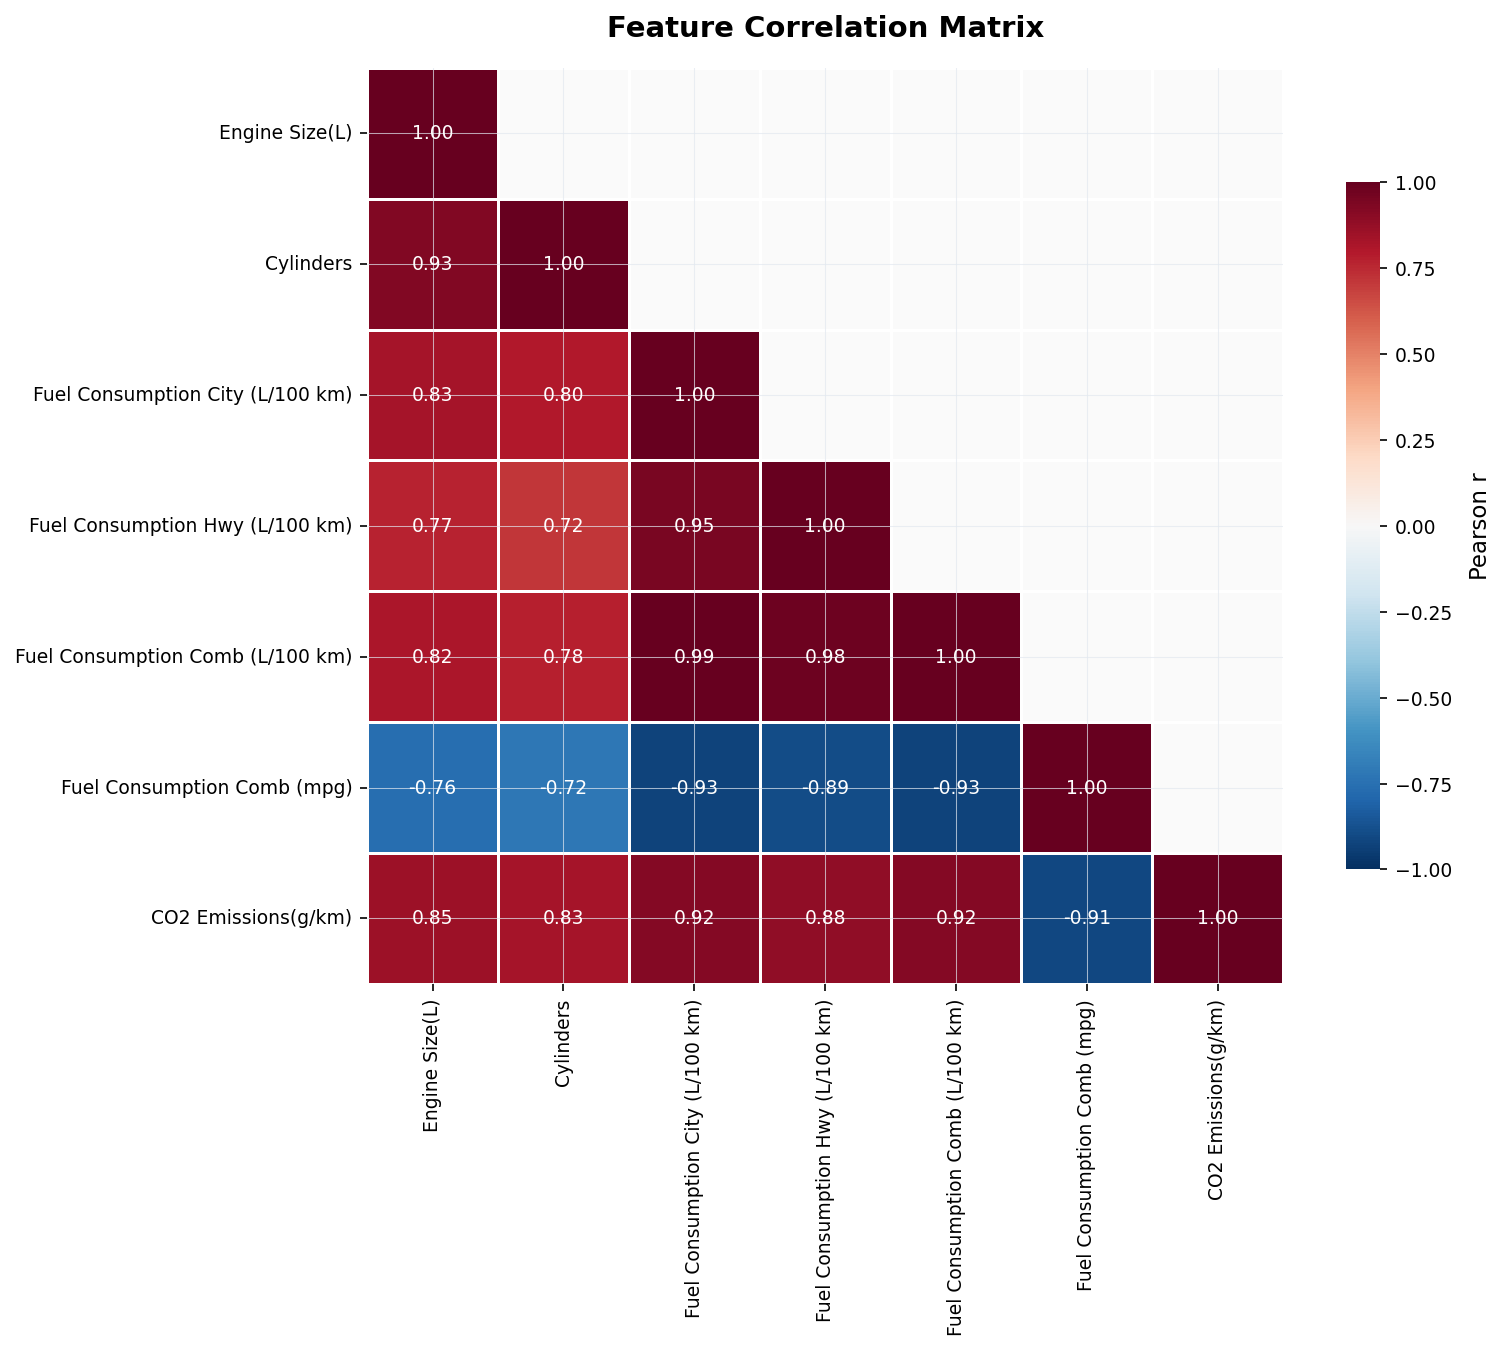

In [14]:
#Correlation heatmap with masked upper triangle for cleaner look
corr_matrix = clean_df[num_cols].corr()
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig1, ax1 = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, mask=mask_upper, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, square=True, ax=ax1,
            annot_kws={'fontsize': 9}, cbar_kws={'shrink': 0.75, 'label': 'Pearson r'})
ax1.set_title('Feature Correlation Matrix', pad=15)
plt.tight_layout()
plt.show()

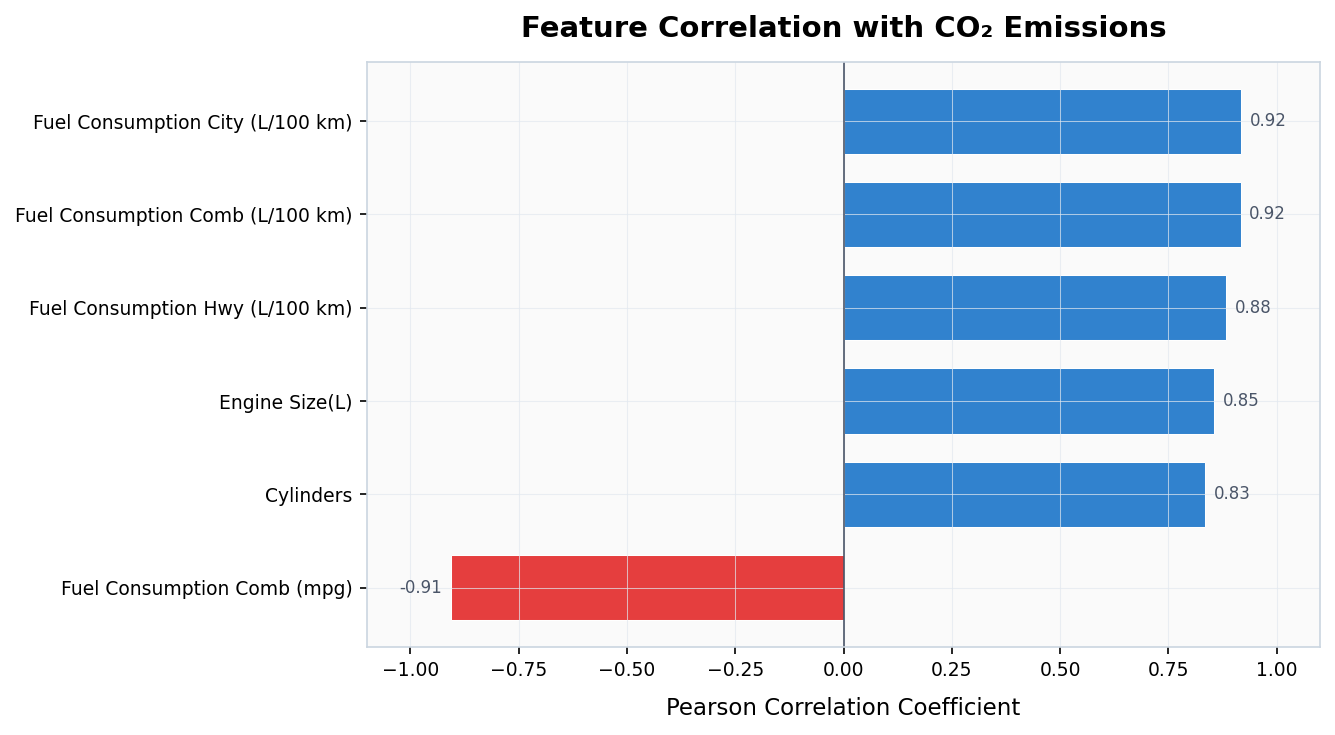

In [15]:
#Bar chart showing each feature's(Labels) correlation with CO2
co2_correlation = corr_matrix['CO2 Emissions(g/km)'].drop('CO2 Emissions(g/km)').sort_values()

fig2, ax2 = plt.subplots(figsize=(9, 5))
bar_clrs = [BLUE if v > 0 else RED for v in co2_correlation.values]
bars = ax2.barh(co2_correlation.index, co2_correlation.values, color=bar_clrs,
                edgecolor='white', linewidth=0.5, height=0.7)
ax2.axvline(x=0, color=SLATE, linewidth=0.8)
for bar, val in zip(bars, co2_correlation.values):
    ax2.text(val + (0.02 if val > 0 else -0.02), bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='left' if val > 0 else 'right', fontsize=8, color=SLATE)
ax2.set_xlabel('Pearson Correlation Coefficient')
ax2.set_title('Feature Correlation with CO₂ Emissions')
ax2.set_xlim(-1.1, 1.1)
plt.tight_layout()
plt.show()

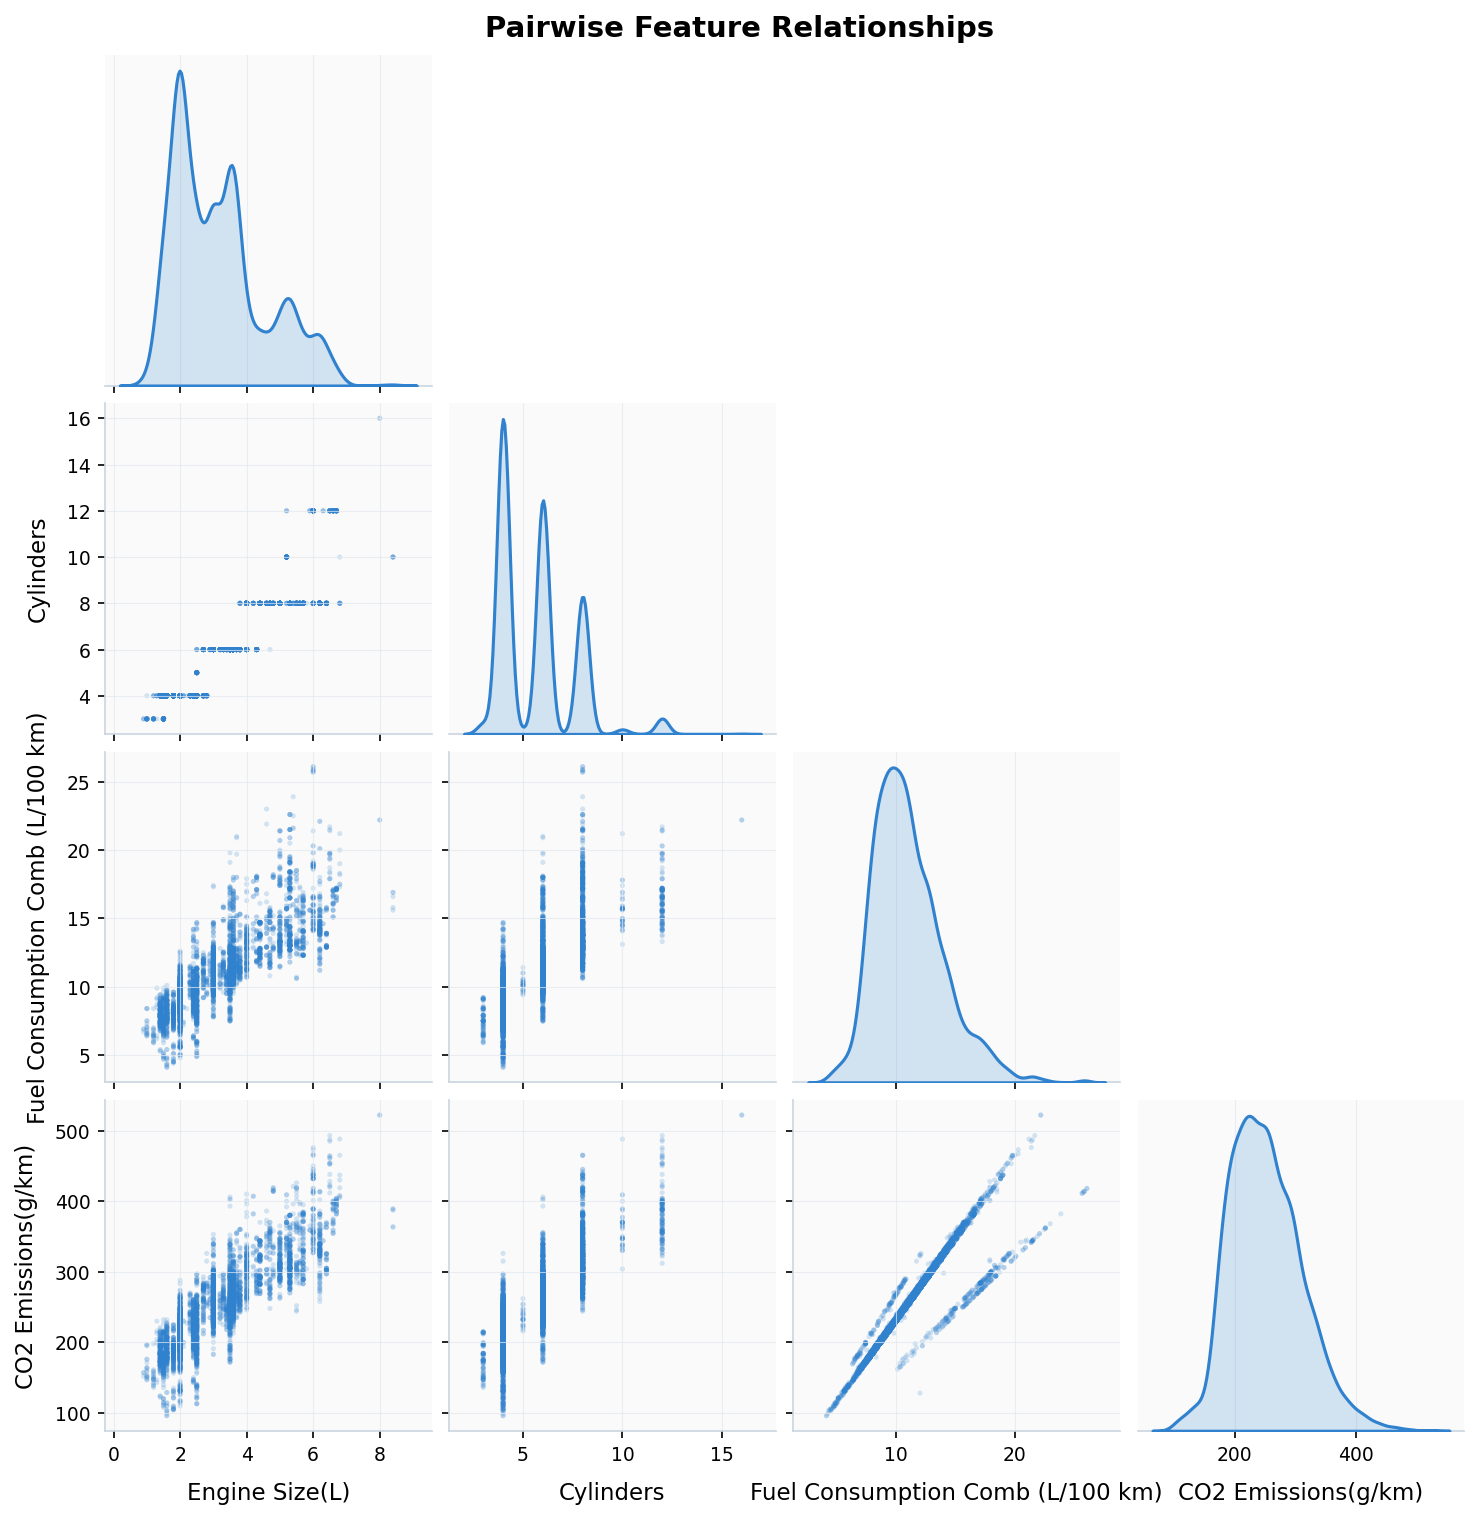

In [16]:
#Pairplot with lower triangle only
main_cols = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)', 'CO2 Emissions(g/km)']
pp = sns.pairplot(clean_df[main_cols], diag_kind='kde', corner=True,
                  plot_kws={'alpha': 0.2, 'color': BLUE, 's': 6, 'edgecolor': 'none', 'rasterized': True},
                  diag_kws={'color': BLUE, 'linewidth': 1.5, 'fill': True, 'alpha': 0.2})
pp.figure.suptitle('Pairwise Feature Relationships', y=1.01, fontsize=14, fontweight='bold')
plt.show()

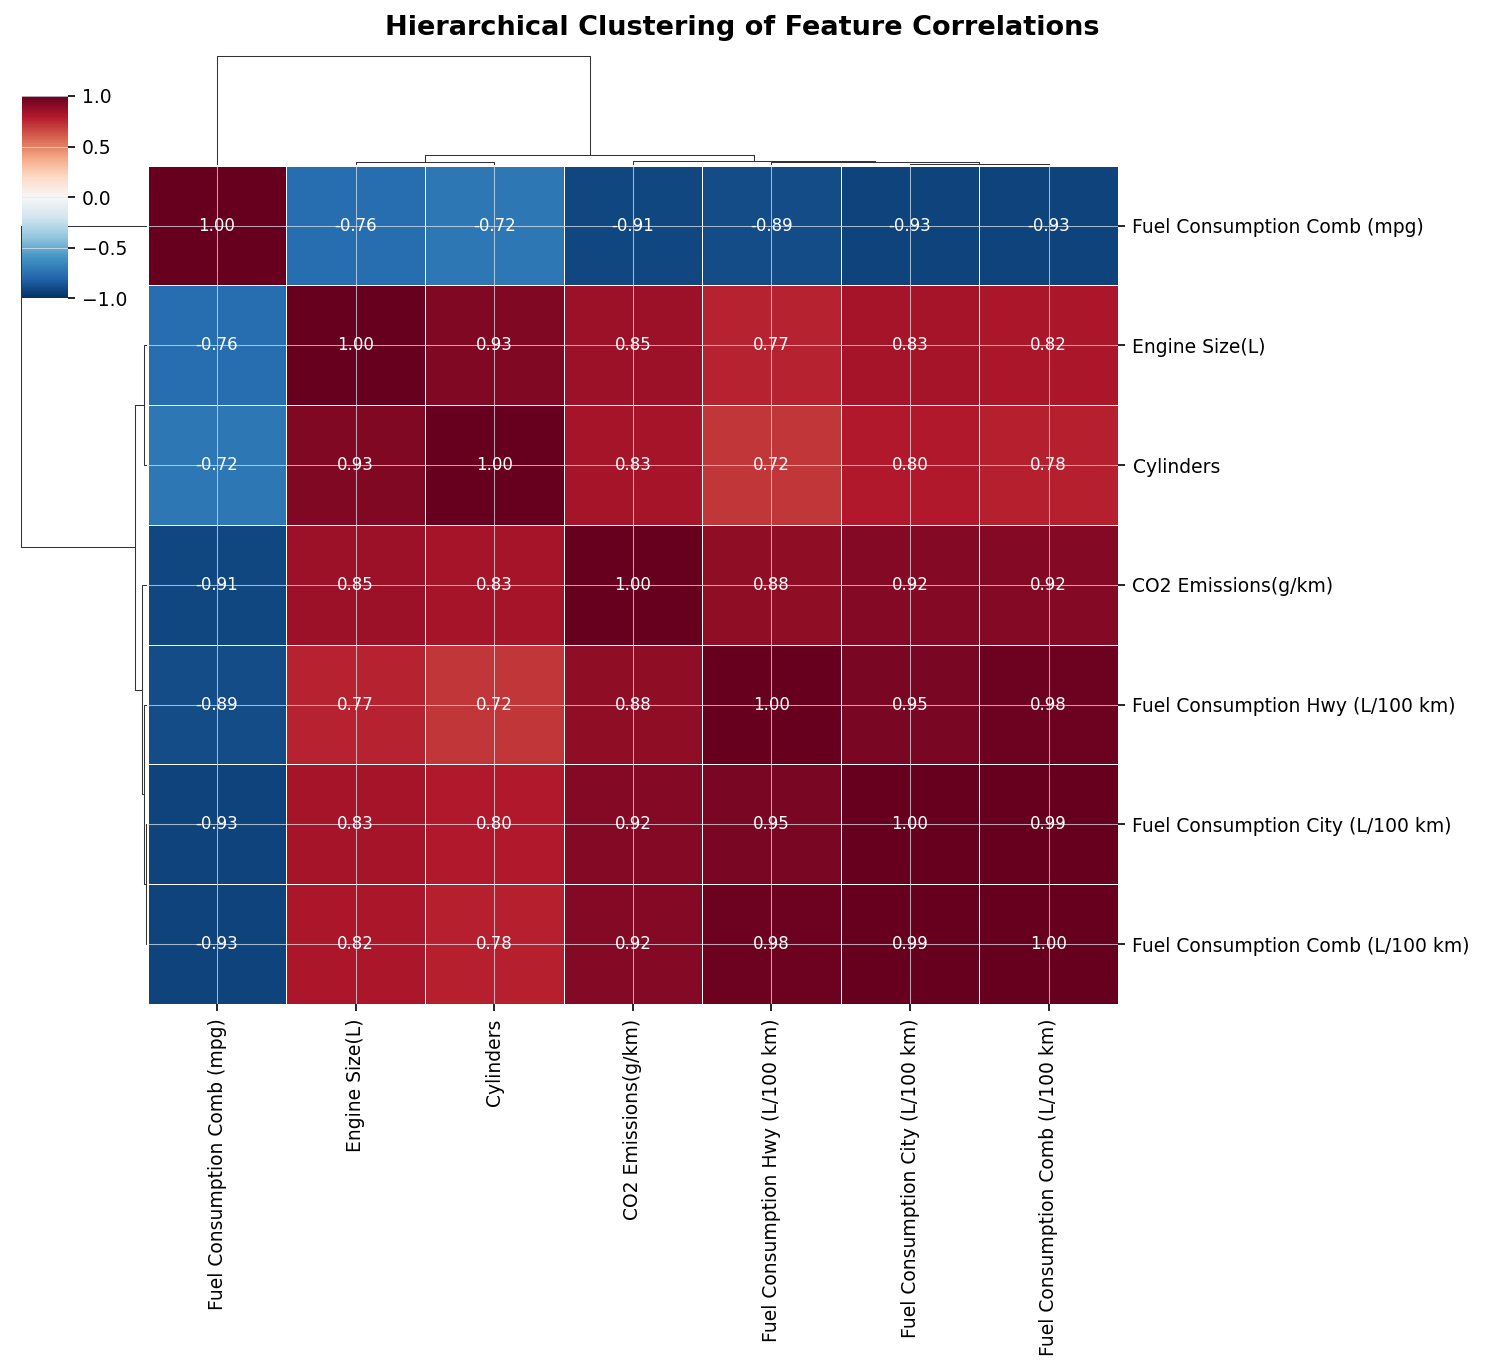

In [17]:
#Hierarchical clustering of feature correlations - dendrogram reveals feature groups
cluster_data = clean_df[num_cols].corr()
cg = sns.clustermap(cluster_data, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                     figsize=(10, 9), linewidths=0.3, vmin=-1, vmax=1,
                     annot_kws={'fontsize': 8}, dendrogram_ratio=(0.12, 0.12),
                     cbar_pos=(0.02, 0.8, 0.03, 0.15))
cg.figure.suptitle('Hierarchical Clustering of Feature Correlations',
                    y=1.01, fontsize=13, fontweight='bold')
plt.show()

In [18]:
#Running ANOVA test on categorical columns to check if they affect CO2
cat_cols = ['Make', 'Vehicle Class', 'Fuel Type', 'Transmission']
anova_list = []

for c in cat_cols:
    groups = [g['CO2 Emissions(g/km)'].values for _, g in clean_df.groupby(c)]
    f_stat, p_value = stats.f_oneway(*groups)
    result = 'Very Significant (p<0.001)' if p_value < 0.001 else ('Significant (p<0.01)' if p_value < 0.01 else 'Not Significant')
    anova_list.append({'Column': c, 'F_Value': round(f_stat, 2), 'P_Value': f'{p_value:.2e}', 'Verdict': result})

anova_df = pd.DataFrame(anova_list)
anova_df

,Column,F_Value,P_Value,Verdict
0,Make,89.83,0.00e+00,Very Significant (p<0.001)
1,Vehicle Class,236.36,0.00e+00,Very Significant (p<0.001)
2,Fuel Type,116.89,2.59e-96,Very Significant (p<0.001)
3,Transmission,85.68,0.00e+00,Very Significant (p<0.001)


**What I found:**
- Combined fuel consumption (L/100 km) has the strongest positive correlation with CO2 (~0.92).
- Engine Size and Cylinders also correlate strongly in the positive direction.
- mpg has a negative correlation which makes sense because higher mileage means less fuel burned.
- ANOVA test shows that all the text columns (Make, Vehicle Class, Fuel Type, Transmission) have a very significant effect on CO₂ emissions (p < 0.001).
- So both numerical and categorical features play a role in determining emissions.

---
## Q4. Visualizing Emission Patterns with Numerical Variables
Let us create different types of plots to see how CO2 emissions change with each numerical feature.

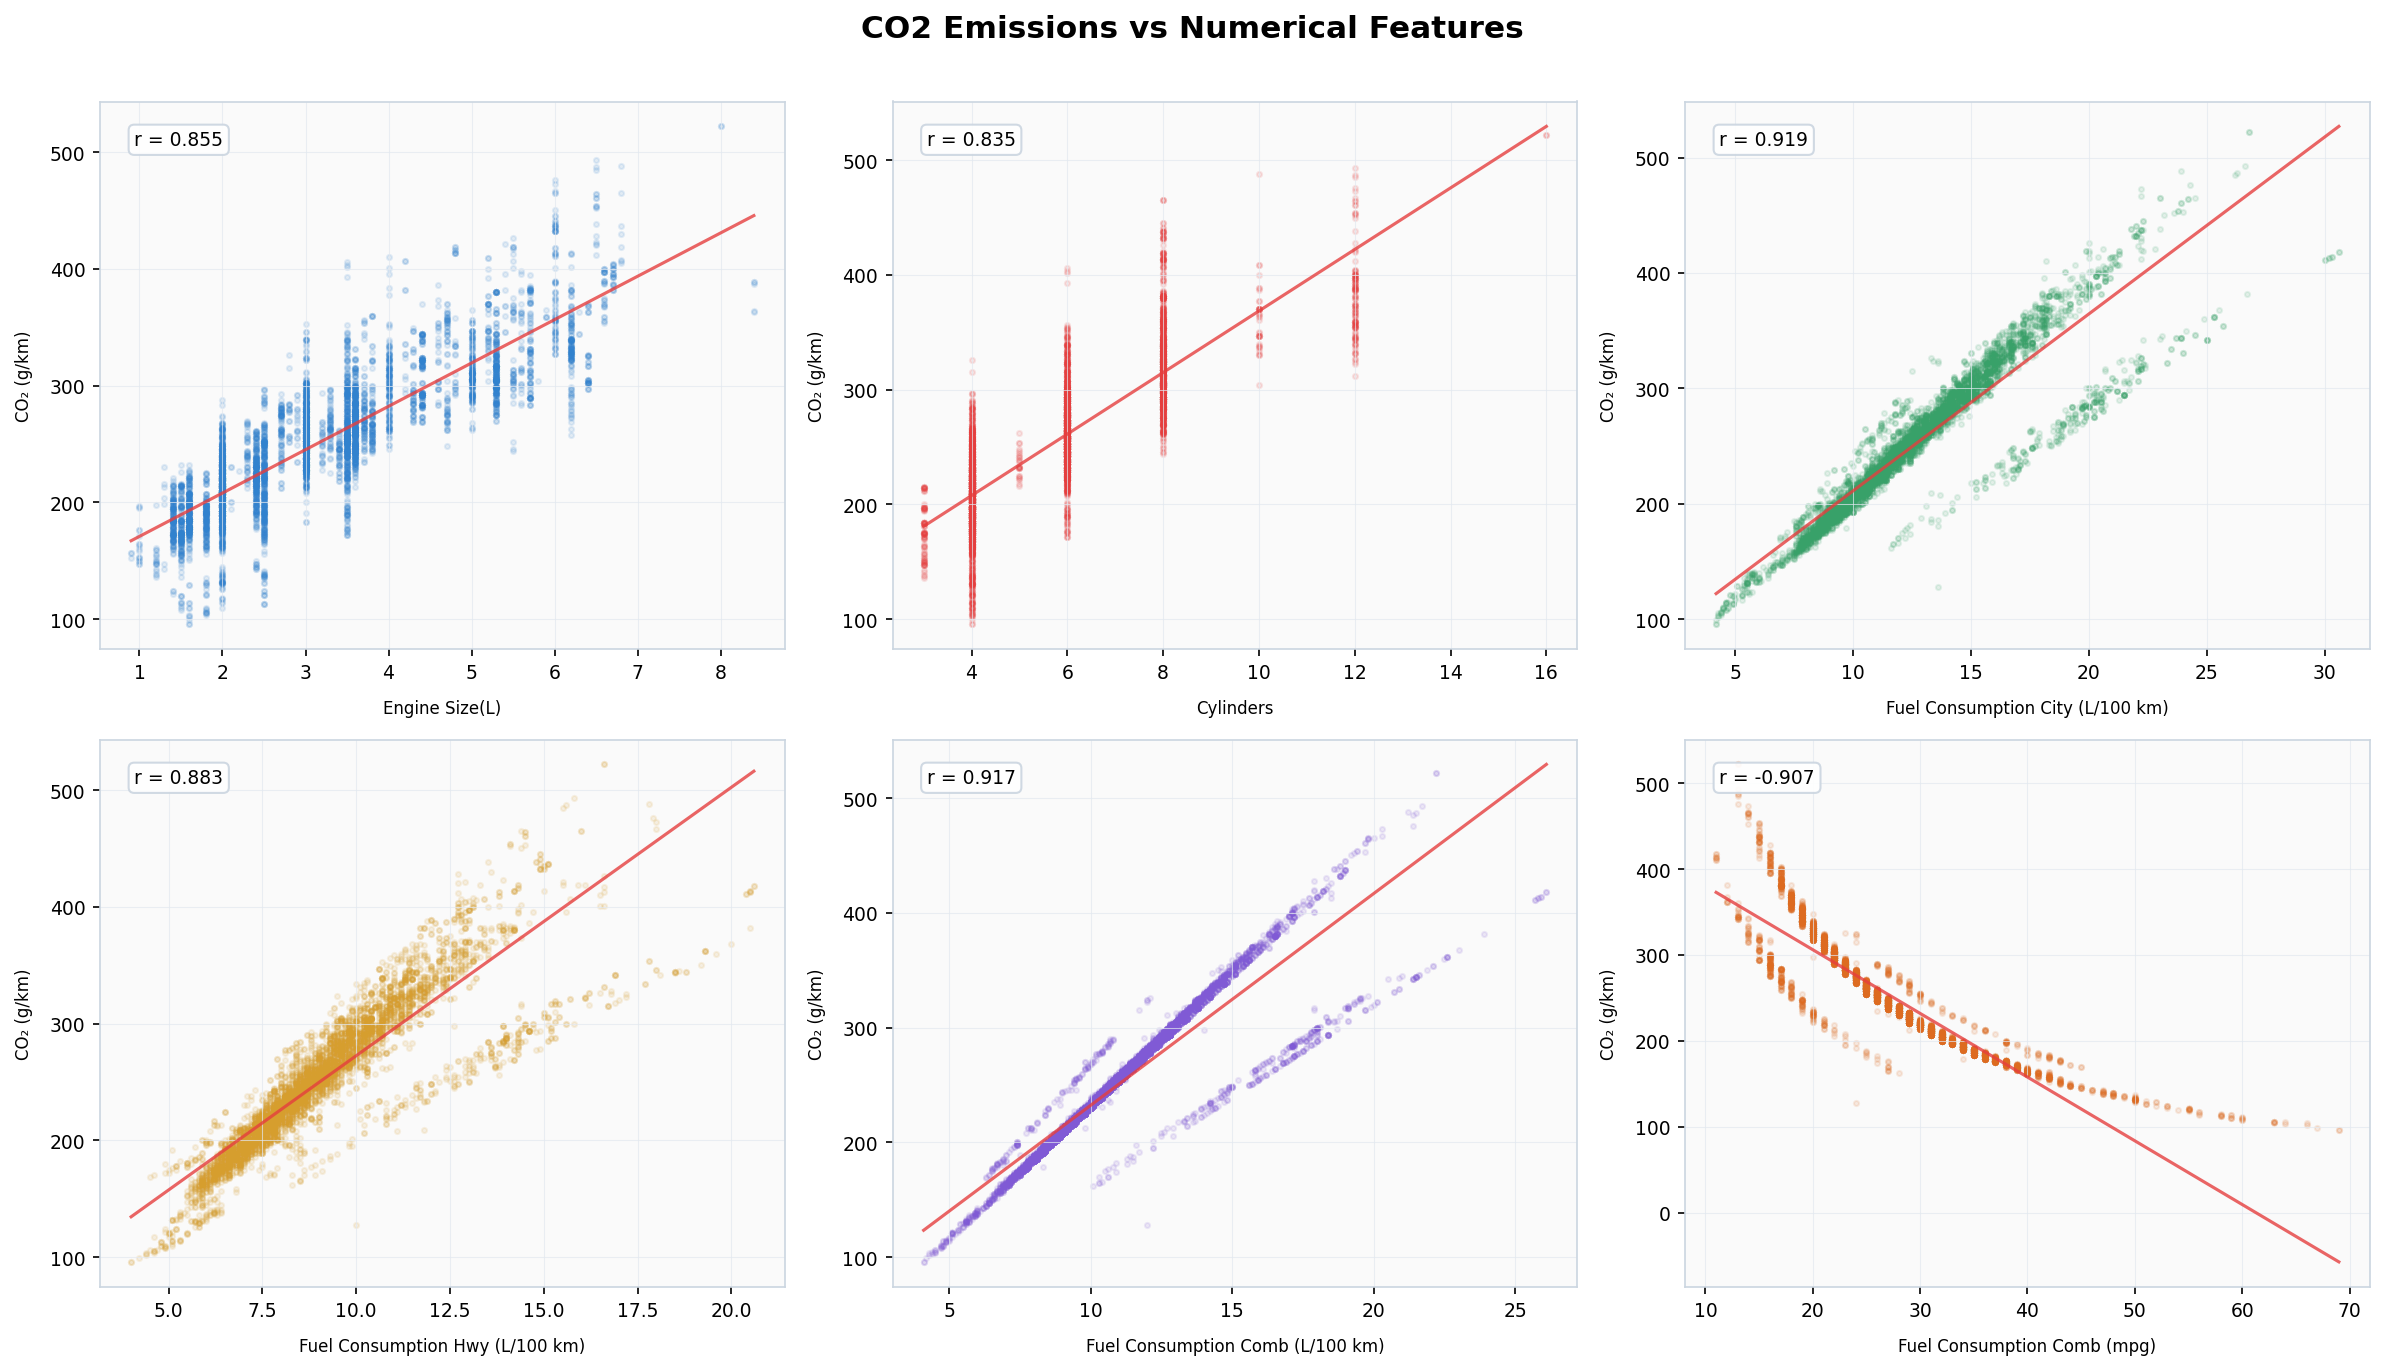

In [19]:
#Scatter plots with trend lines and correlation values
plot_cols = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
             'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
             'Fuel Consumption Comb (mpg)']

fig3, axes3 = plt.subplots(2, 3, figsize=(16, 9))
flat_axes = axes3.flatten()

for k, col in enumerate(plot_cols):
    ax = flat_axes[k]
    ax.scatter(clean_df[col], clean_df['CO2 Emissions(g/km)'],
               alpha=0.12, s=6, color=PAL[k], rasterized=True)
    # trend line
    z = np.polyfit(clean_df[col].dropna(), clean_df.loc[clean_df[col].notna(), 'CO2 Emissions(g/km)'], 1)
    xr = np.linspace(clean_df[col].min(), clean_df[col].max(), 100)
    ax.plot(xr, np.polyval(z, xr), color=RED, linewidth=1.5, alpha=0.8)
    r_val = clean_df[col].corr(clean_df['CO2 Emissions(g/km)'])
    ax.text(0.05, 0.92, f'r = {r_val:.3f}', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#CBD5E0', alpha=0.9))
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('CO₂ (g/km)', fontsize=8)

fig3.suptitle('CO2 Emissions vs Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

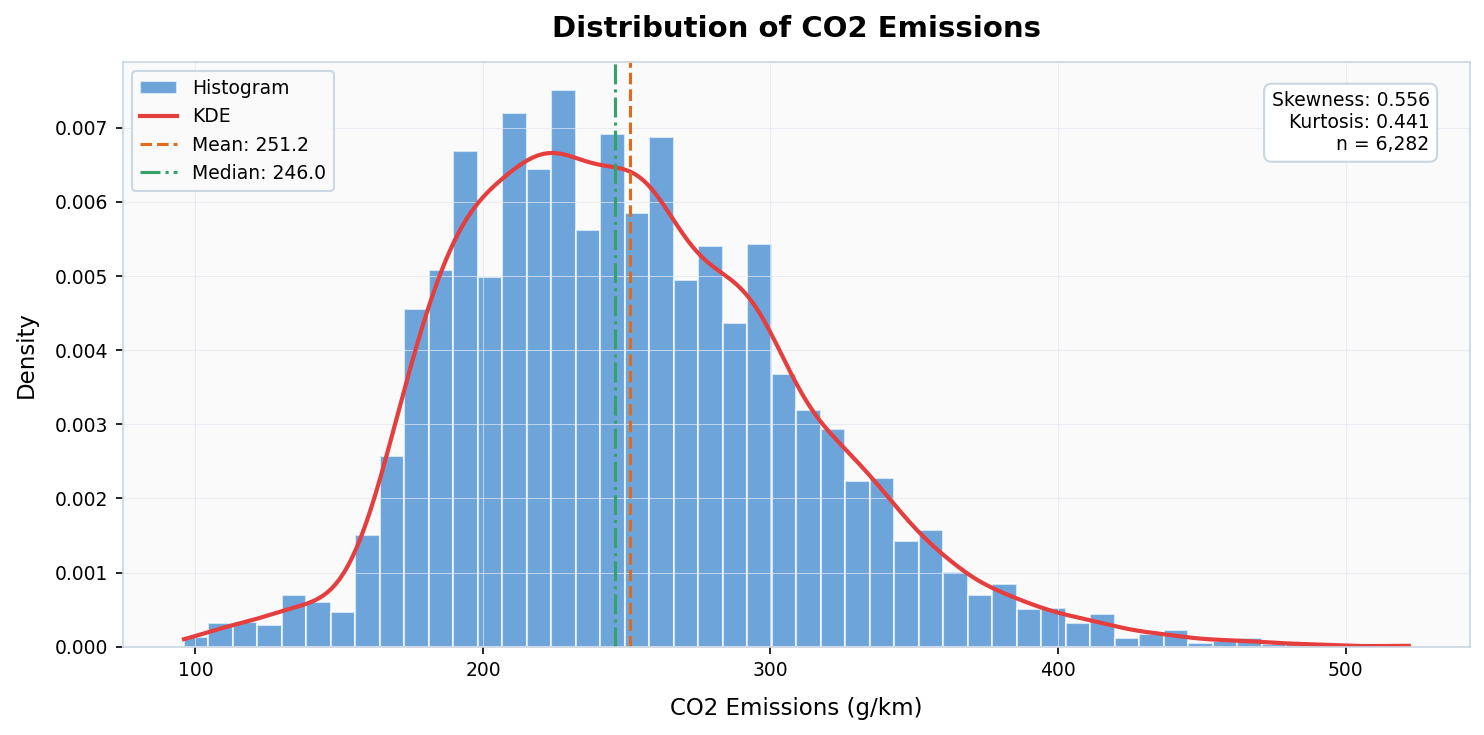

In [20]:
#Distribution of CO2 with KDE overlay and statistics
fig4, ax4 = plt.subplots(figsize=(10, 5))
ax4.hist(clean_df['CO2 Emissions(g/km)'], bins=50, color=BLUE, edgecolor='white',
         alpha=0.7, density=True, label='Histogram')
kde_x = np.linspace(clean_df['CO2 Emissions(g/km)'].min(), clean_df['CO2 Emissions(g/km)'].max(), 300)
kde_fn = stats.gaussian_kde(clean_df['CO2 Emissions(g/km)'])
ax4.plot(kde_x, kde_fn(kde_x), color=RED, linewidth=2, label='KDE')
mu = clean_df['CO2 Emissions(g/km)'].mean()
med = clean_df['CO2 Emissions(g/km)'].median()
ax4.axvline(mu, color=ORANGE, linestyle='--', linewidth=1.5, label=f'Mean: {mu:.1f}')
ax4.axvline(med, color=GREEN, linestyle='-.', linewidth=1.5, label=f'Median: {med:.1f}')
skew_val = clean_df['CO2 Emissions(g/km)'].skew()
kurt_val = clean_df['CO2 Emissions(g/km)'].kurtosis()
ax4.text(0.97, 0.95, f'Skewness: {skew_val:.3f}\nKurtosis: {kurt_val:.3f}\nn = {len(clean_df):,}',
         transform=ax4.transAxes, va='top', ha='right', fontsize=9,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#CBD5E0'))
ax4.set_xlabel('CO2 Emissions (g/km)')
ax4.set_ylabel('Density')
ax4.set_title('Distribution of CO2 Emissions')
ax4.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

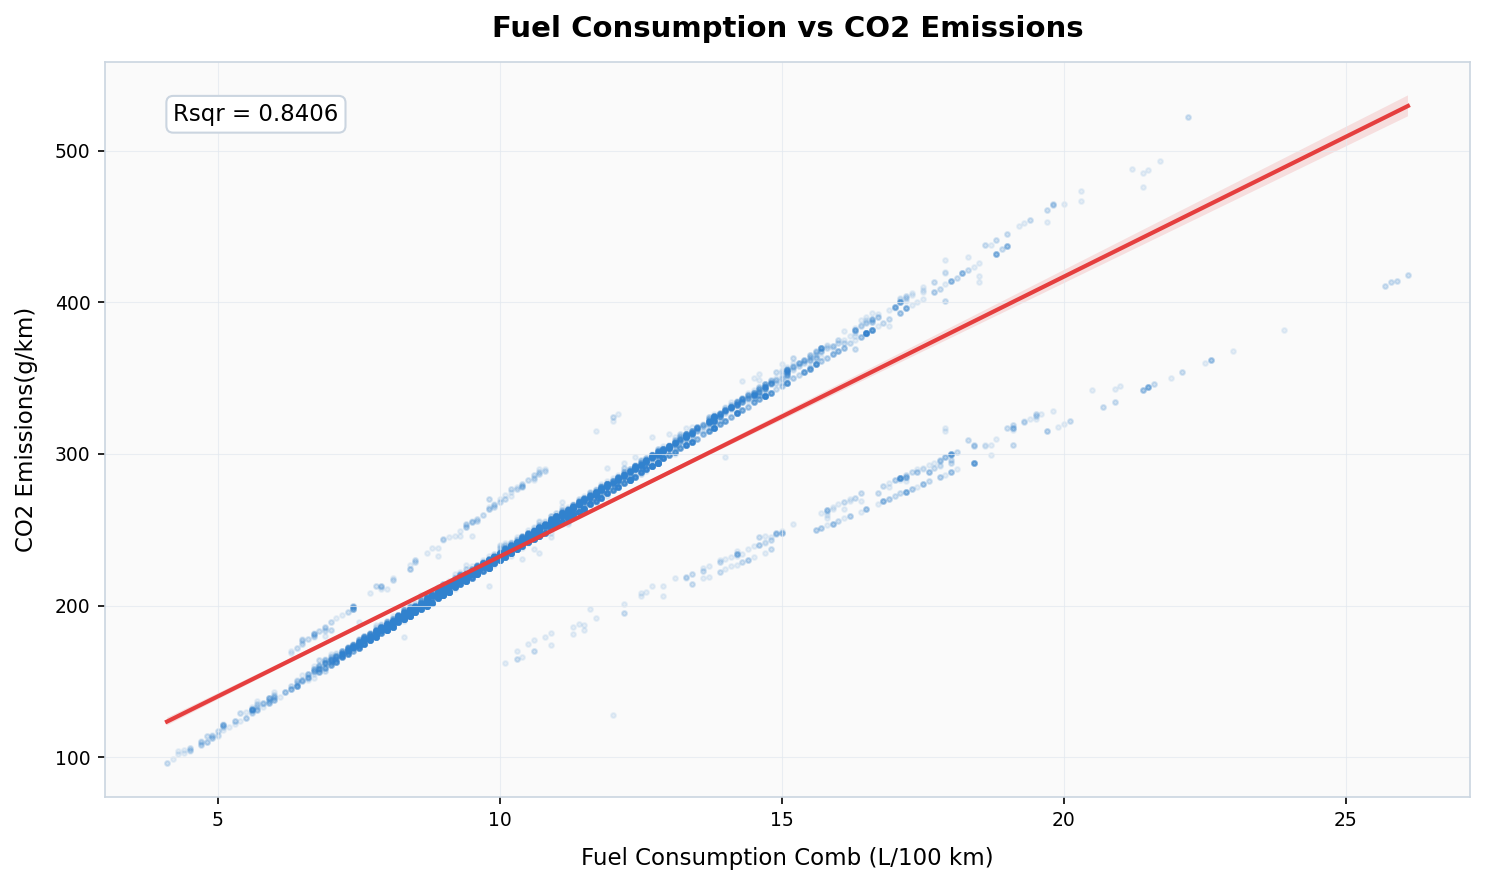

In [21]:
#Regression plot with 95% confidence interval and Rsqr annotation
fig5, ax5 = plt.subplots(figsize=(10, 6))
sns.regplot(x='Fuel Consumption Comb (L/100 km)', y='CO2 Emissions(g/km)',
            data=clean_df, scatter_kws={'alpha': 0.1, 's': 5, 'color': BLUE, 'rasterized': True},
            line_kws={'color': RED, 'linewidth': 2}, ci=95, ax=ax5)
r_sq = clean_df['Fuel Consumption Comb (L/100 km)'].corr(clean_df['CO2 Emissions(g/km)']) ** 2
ax5.text(0.05, 0.92, f'Rsqr = {r_sq:.4f}', transform=ax5.transAxes, fontsize=11,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#CBD5E0'))
ax5.set_title('Fuel Consumption vs CO2 Emissions')
plt.tight_layout()
plt.show()

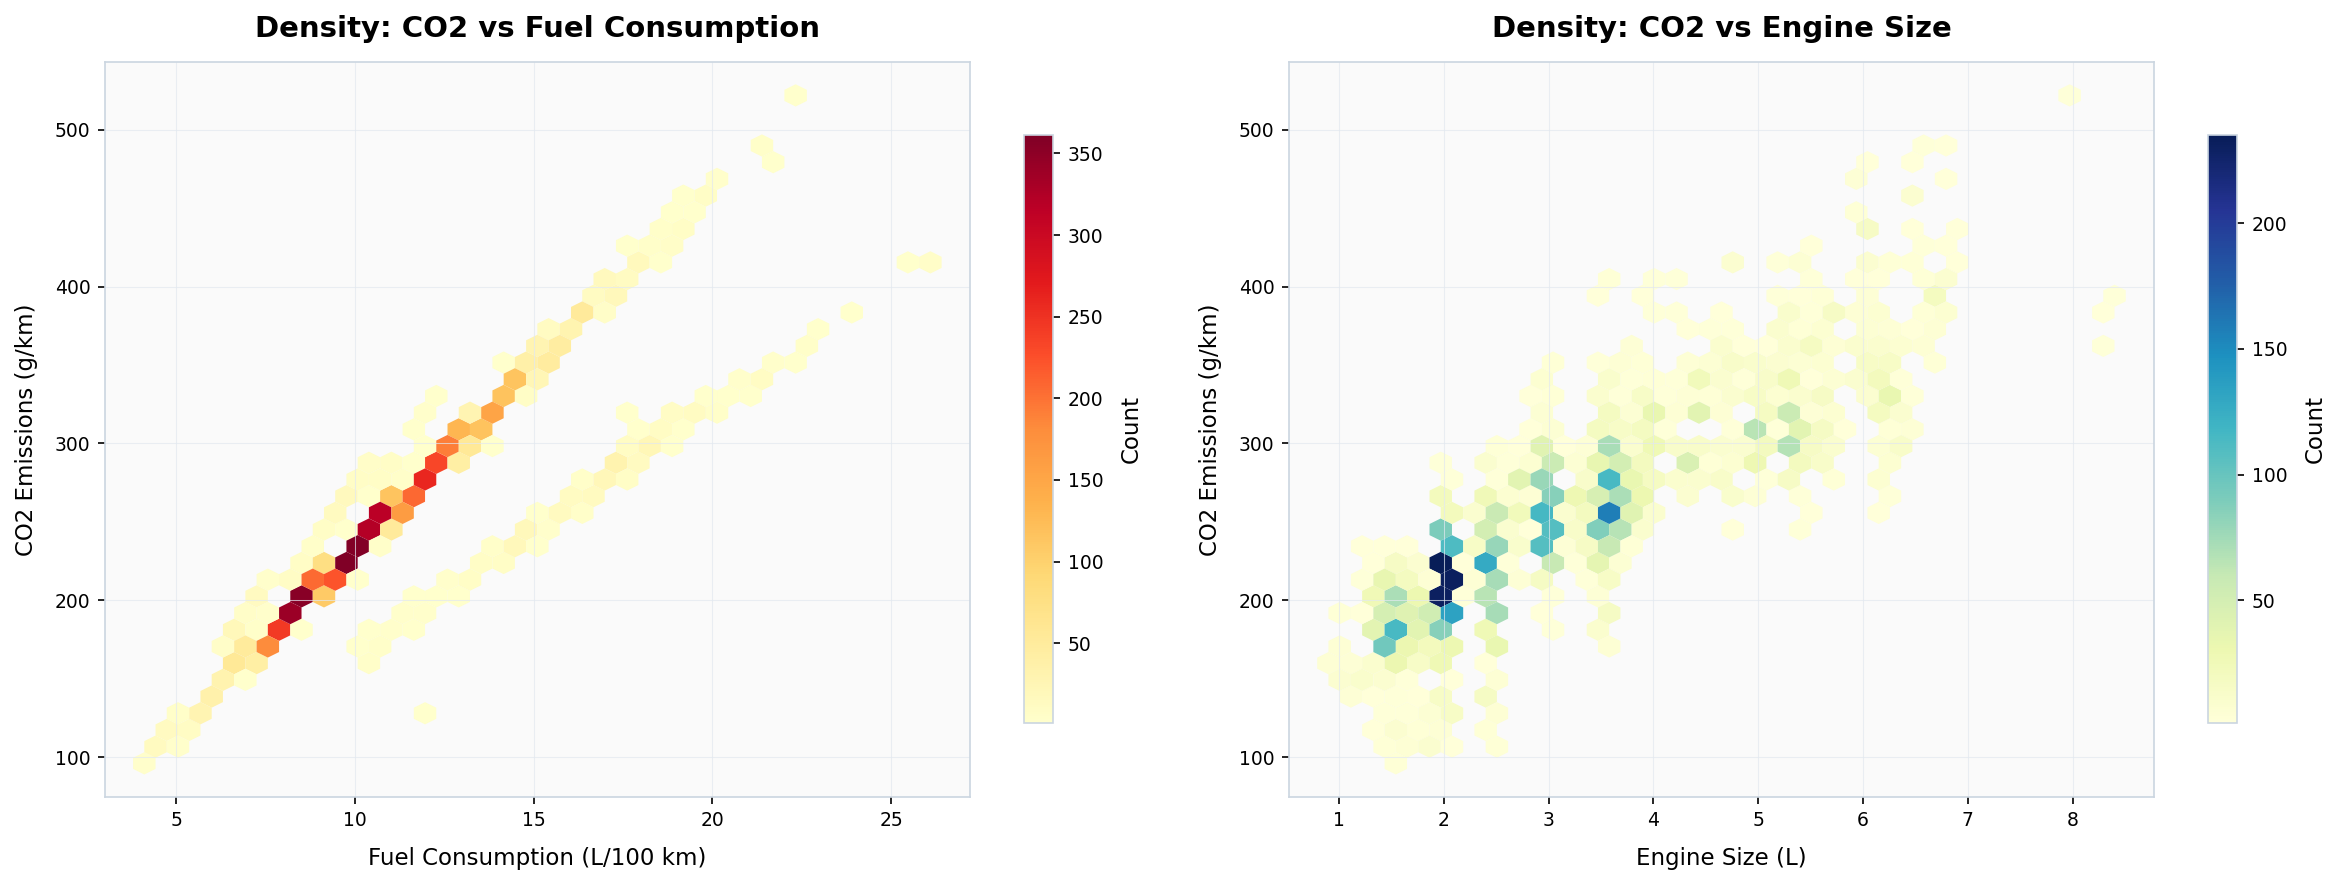

In [22]:
#Hexbin density plots showing data concentration
fig6, (ax6a, ax6b) = plt.subplots(1, 2, figsize=(16, 6))

hb1 = ax6a.hexbin(clean_df['Fuel Consumption Comb (L/100 km)'], clean_df['CO2 Emissions(g/km)'],
                   gridsize=35, cmap='YlOrRd', mincnt=1, edgecolors='none')
ax6a.set_xlabel('Fuel Consumption (L/100 km)')
ax6a.set_ylabel('CO2 Emissions (g/km)')
ax6a.set_title('Density: CO2 vs Fuel Consumption')
plt.colorbar(hb1, ax=ax6a, label='Count', shrink=0.8)

hb2 = ax6b.hexbin(clean_df['Engine Size(L)'], clean_df['CO2 Emissions(g/km)'],
                   gridsize=35, cmap='YlGnBu', mincnt=1, edgecolors='none')
ax6b.set_xlabel('Engine Size (L)')
ax6b.set_ylabel('CO2 Emissions (g/km)')
ax6b.set_title('Density: CO2 vs Engine Size')
plt.colorbar(hb2, ax=ax6b, label='Count', shrink=0.8)

plt.tight_layout()
plt.show()

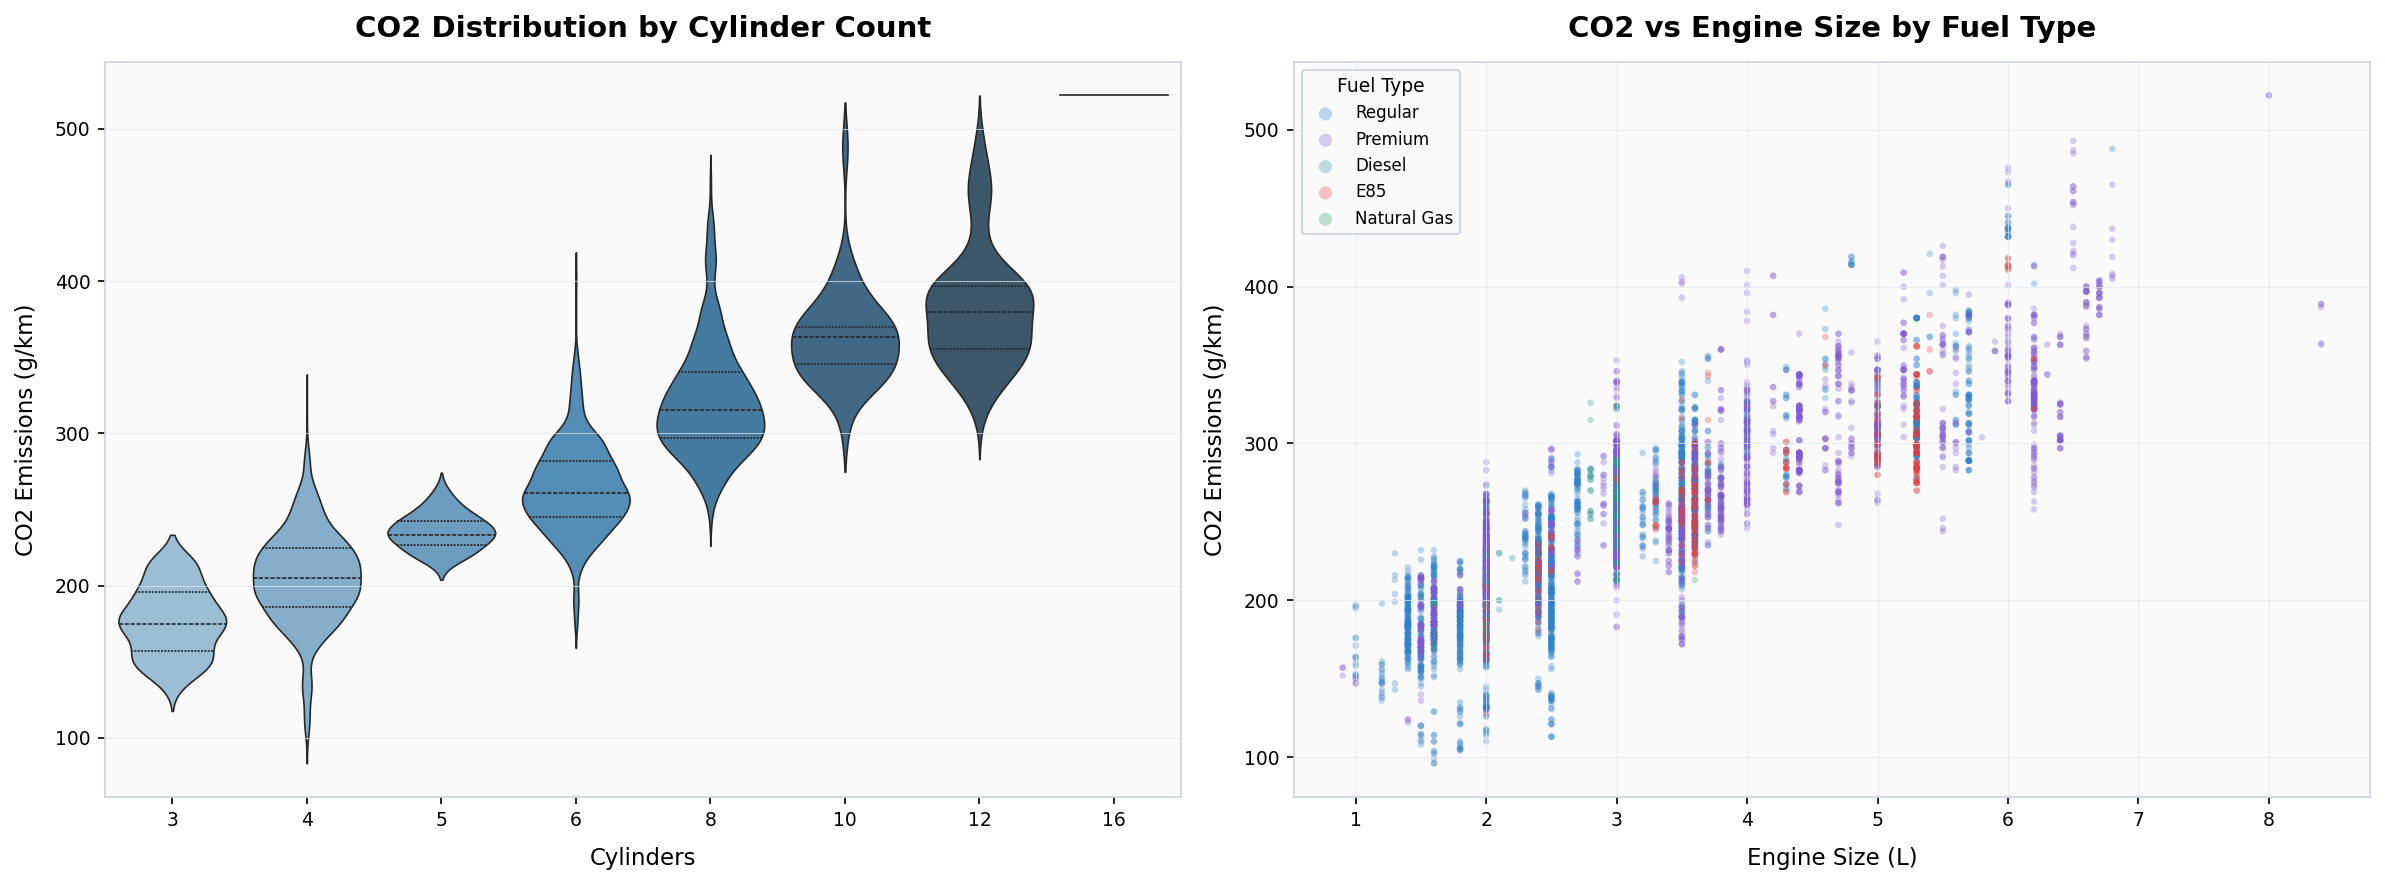

In [23]:
#Violin plot for cylinders and scatter by fuel type
fig7, (ax7a, ax7b) = plt.subplots(1, 2, figsize=(16, 6))

cyl_pal = sns.color_palette('Blues_d', n_colors=clean_df['Cylinders'].nunique())
sns.violinplot(x='Cylinders', y='CO2 Emissions(g/km)', data=clean_df,
               palette=cyl_pal, inner='quartile', linewidth=0.8, ax=ax7a)
ax7a.set_title('CO2 Distribution by Cylinder Count')
ax7a.set_ylabel('CO2 Emissions (g/km)')

fuel_pal = {'X': BLUE, 'Z': PURPLE, 'D': TEAL, 'E': RED, 'N': GREEN}
fuel_labels = {'X': 'Regular', 'Z': 'Premium', 'D': 'Diesel', 'E': 'E85', 'N': 'Natural Gas'}
for ft, fc in fuel_pal.items():
    subset = clean_df[clean_df['Fuel Type'] == ft]
    if len(subset) > 0:
        ax7b.scatter(subset['Engine Size(L)'], subset['CO2 Emissions(g/km)'],
                     alpha=0.3, s=10, color=fc, label=fuel_labels[ft],
                     edgecolors='none', rasterized=True)
ax7b.set_title('CO2 vs Engine Size by Fuel Type')
ax7b.set_xlabel('Engine Size (L)')
ax7b.set_ylabel('CO2 Emissions (g/km)')
ax7b.legend(title='Fuel Type', fontsize=8, title_fontsize=9, markerscale=2)

plt.tight_layout()
plt.show()

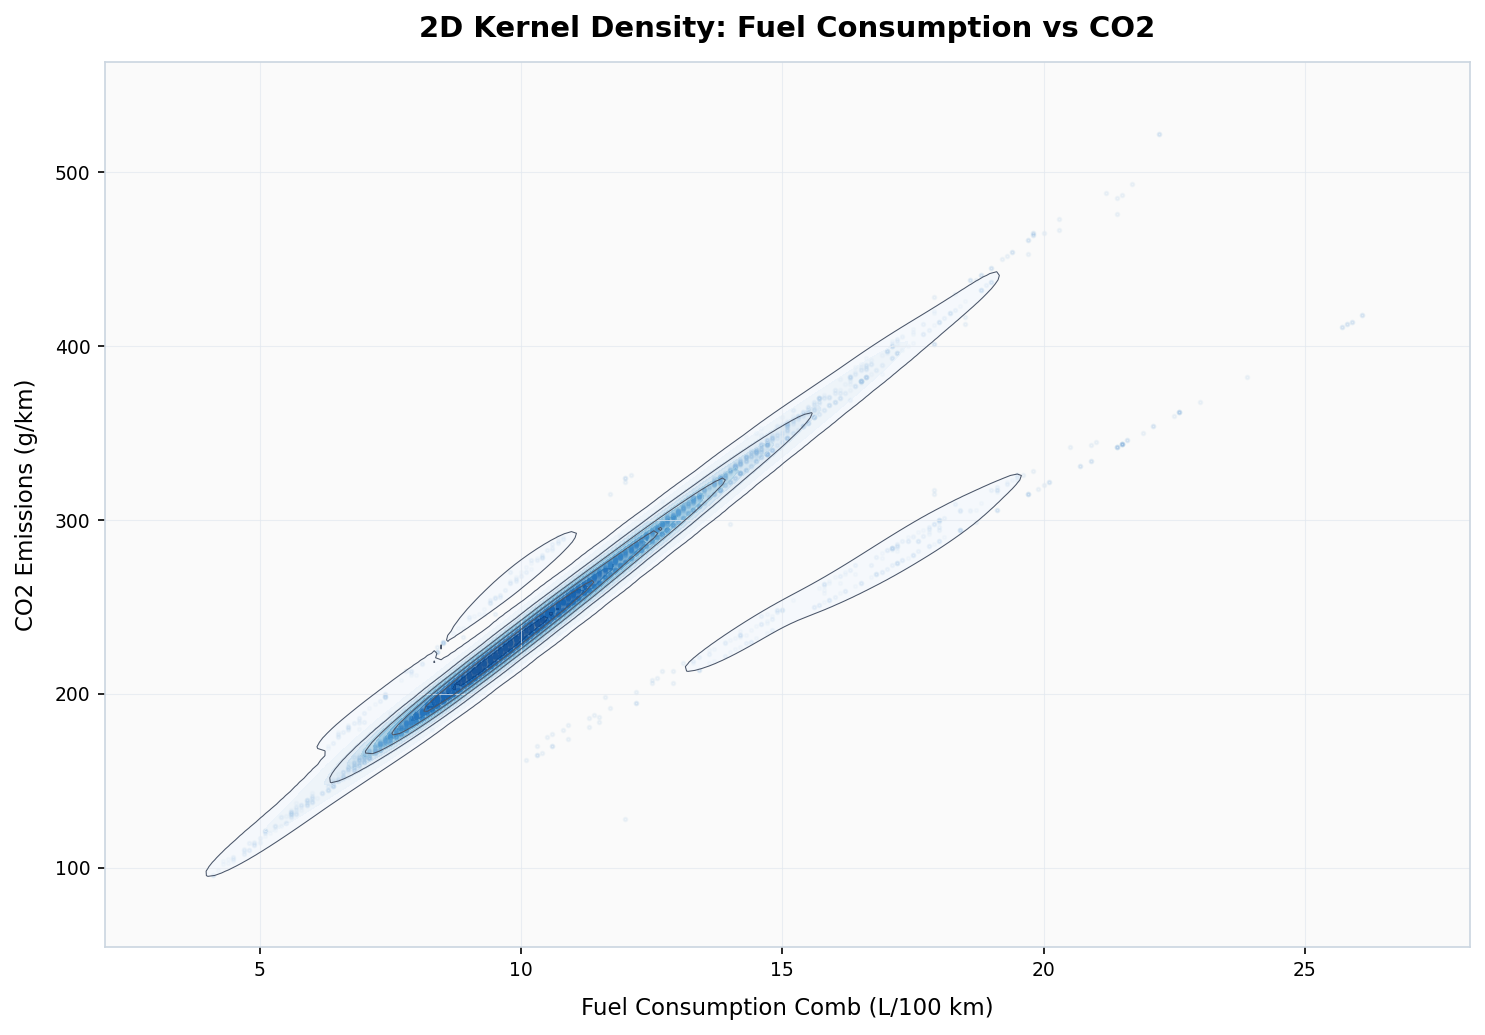

In [24]:
#2D KDE contour plot showing data concentration zones
fig_kde, ax_kde = plt.subplots(figsize=(10, 7))
ax_kde.scatter(clean_df['Fuel Consumption Comb (L/100 km)'], clean_df['CO2 Emissions(g/km)'],
               s=3, alpha=0.05, color=BLUE, rasterized=True)
sns.kdeplot(data=clean_df, x='Fuel Consumption Comb (L/100 km)', y='CO2 Emissions(g/km)',
            cmap='Blues', fill=True, levels=12, thresh=0.05, ax=ax_kde, alpha=0.6)
sns.kdeplot(data=clean_df, x='Fuel Consumption Comb (L/100 km)', y='CO2 Emissions(g/km)',
            color=SLATE, levels=6, linewidths=0.5, ax=ax_kde)
ax_kde.set_xlabel('Fuel Consumption Comb (L/100 km)')
ax_kde.set_ylabel('CO2 Emissions (g/km)')
ax_kde.set_title('2D Kernel Density: Fuel Consumption vs CO2')
plt.tight_layout()
plt.show()

**What I found:**
- There is a clear straight-line pattern between fuel consumption and CO2 emissions.
- Cars with bigger engines and more cylinders give out more CO2.
- Most cars fall in the 200-300 g/km range and the distribution is a bit skewed to the right.
- mpg shows a curved inverse relationship with emissions.

---
## Q5. Comparing Emissions Across Vehicle Types and Fuel Categories
Let us compare how CO2 emissions differ between different vehicle classes and fuel types.

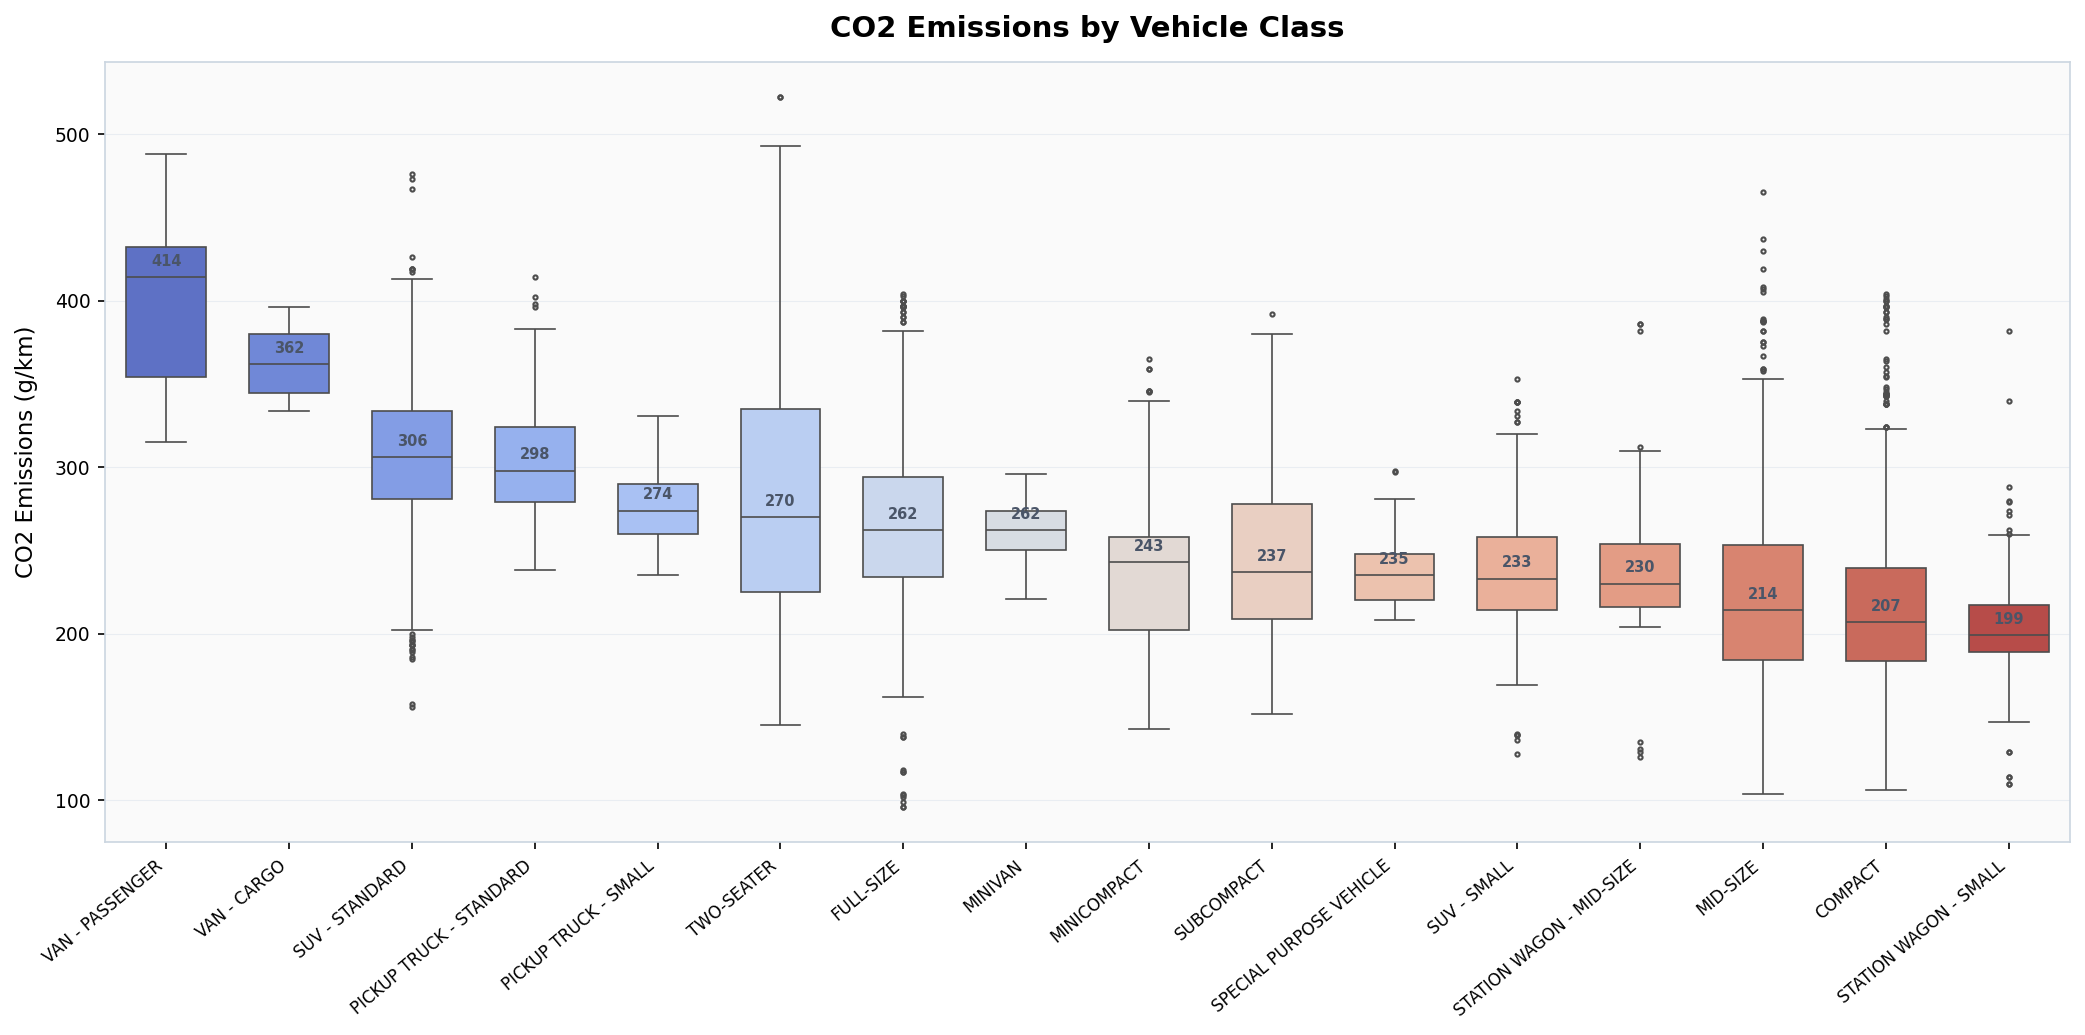

In [25]:
#Boxplot by vehicle class with median annotations
sorted_classes = clean_df.groupby('Vehicle Class')['CO2 Emissions(g/km)'].median().sort_values(ascending=False).index

fig8, ax8 = plt.subplots(figsize=(14, 7))
box_pal = sns.color_palette('coolwarm', n_colors=len(sorted_classes))
sns.boxplot(x='Vehicle Class', y='CO2 Emissions(g/km)', data=clean_df,
            order=sorted_classes, palette=box_pal, ax=ax8, fliersize=2,
            linewidth=0.8, width=0.65)
medians = clean_df.groupby('Vehicle Class')['CO2 Emissions(g/km)'].median().reindex(sorted_classes)
for i, val in enumerate(medians):
    ax8.text(i, val + 5, f'{val:.0f}', ha='center', va='bottom', fontsize=7,
             fontweight='bold', color=SLATE)
ax8.set_xticklabels(ax8.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax8.set_title('CO2 Emissions by Vehicle Class')
ax8.set_ylabel('CO2 Emissions (g/km)')
ax8.set_xlabel('')
plt.tight_layout()
plt.show()

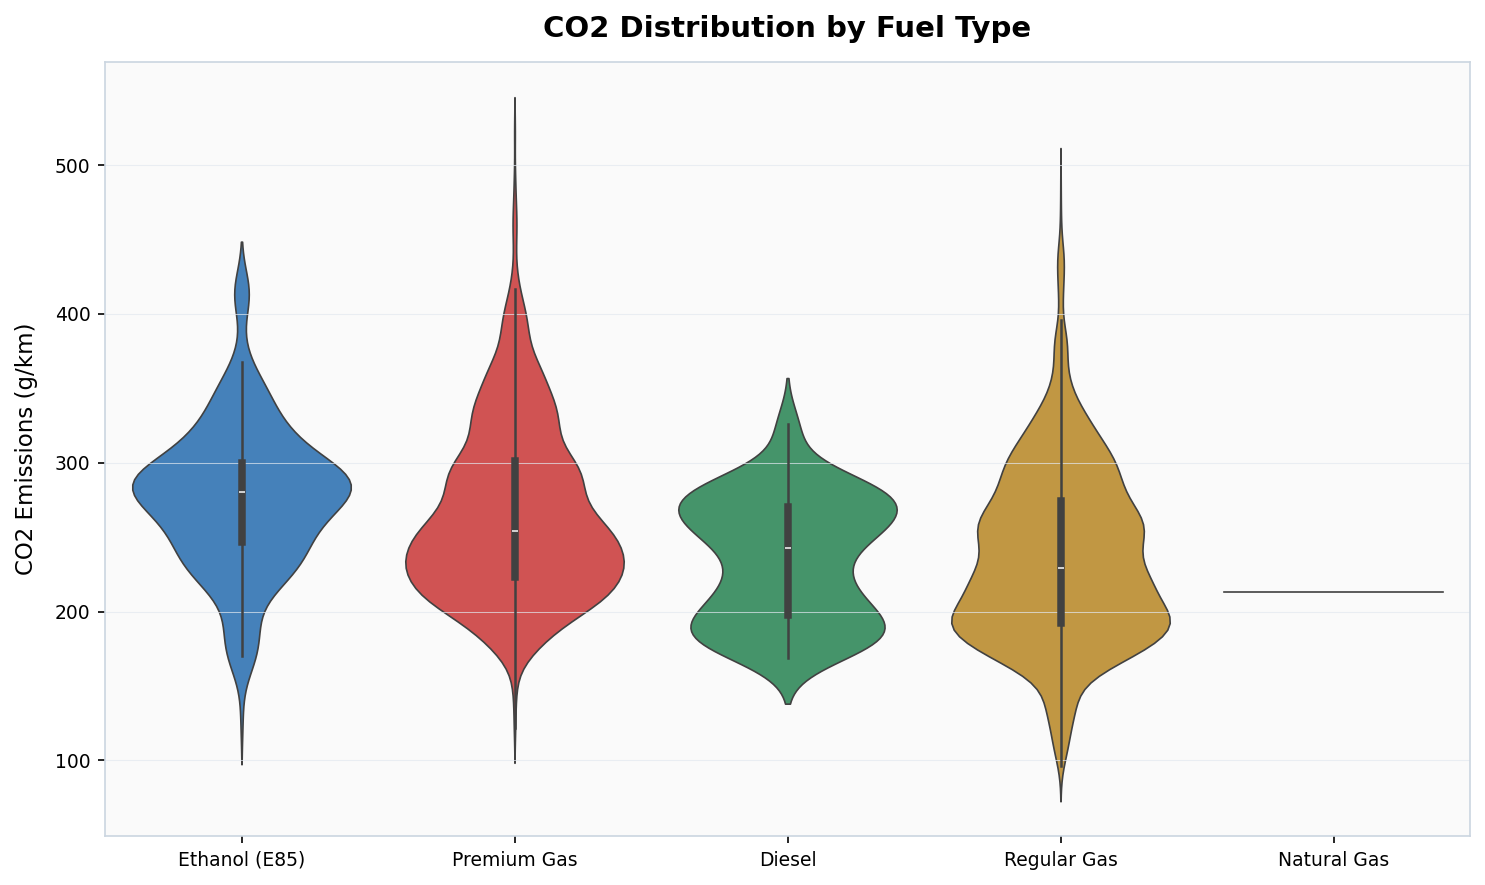

In [26]:
#CO2 distribution by fuel type - violin with ordered categories
fuel_names = {'X': 'Regular Gas', 'Z': 'Premium Gas', 'D': 'Diesel', 'E': 'Ethanol (E85)', 'N': 'Natural Gas'}
clean_df['Fuel_Name'] = clean_df['Fuel Type'].map(fuel_names)

fig9, ax9 = plt.subplots(figsize=(10, 6))
fuel_order = clean_df.groupby('Fuel_Name')['CO2 Emissions(g/km)'].median().sort_values(ascending=False).index
viol_pal = {name: PAL[i] for i, name in enumerate(fuel_order)}
sns.violinplot(x='Fuel_Name', y='CO2 Emissions(g/km)', data=clean_df,
               order=fuel_order, palette=viol_pal, inner='box', linewidth=0.8, ax=ax9)
ax9.set_title('CO2 Distribution by Fuel Type')
ax9.set_xlabel('')
ax9.set_ylabel('CO2 Emissions (g/km)')
plt.tight_layout()
plt.show()

In [27]:
#Average CO2 stats grouped by fuel type
fuel_stats = clean_df.groupby('Fuel_Name')['CO2 Emissions(g/km)'].agg(['mean', 'median', 'std', 'count'])
fuel_stats.columns = ['Avg_CO2', 'Mid_CO2', 'StdDev', 'Total_Cars']
fuel_stats.sort_values('Avg_CO2', ascending=False)

,Avg_CO2,Mid_CO2,StdDev,Total_Cars
Fuel_Name,,,,
Ethanol (E85),276.048485,280.0,48.742211,330
Premium Gas,265.731284,254.0,57.643169,2765
Regular Gas,235.977953,229.0,58.303652,3039
Diesel,235.238095,243.0,41.911736,147
Natural Gas,213.000000,213.0,NaN,1


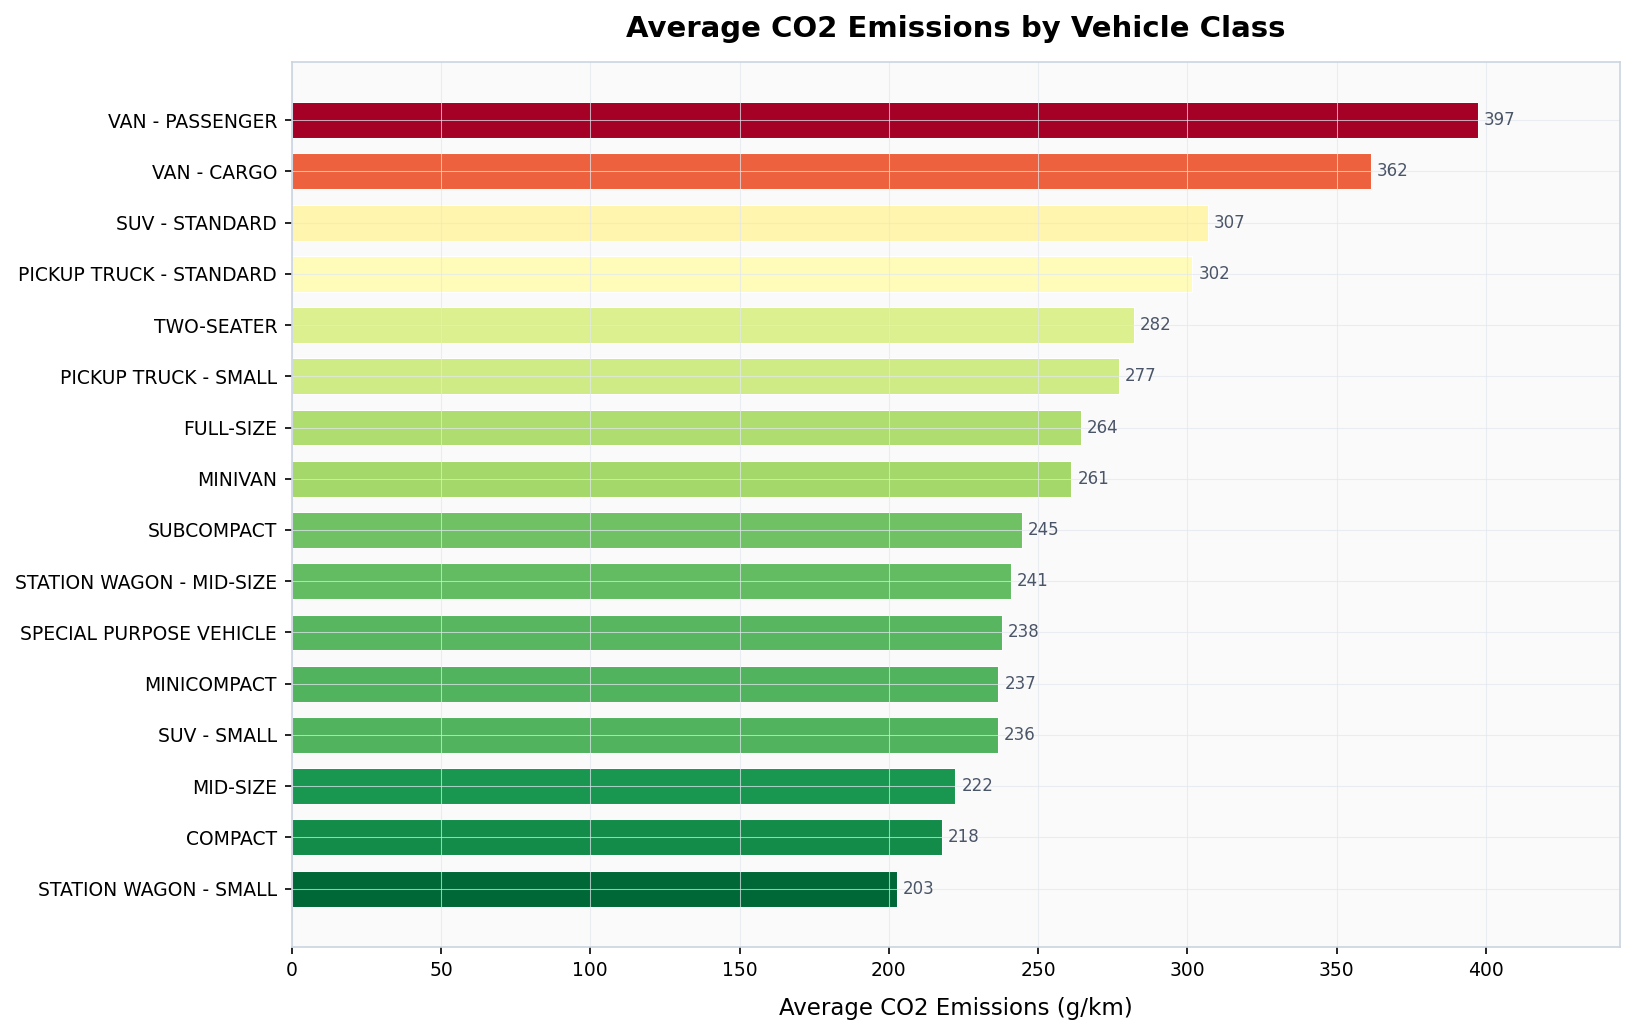

In [28]:
#Average CO2 by vehicle class with semantic color gradient (green=low, red=high)
avg_by_class = clean_df.groupby('Vehicle Class')['CO2 Emissions(g/km)'].mean().sort_values()

fig10, ax10 = plt.subplots(figsize=(11, 7))
vals = avg_by_class.values
norm_vals = (vals - vals.min()) / (vals.max() - vals.min())
bar_colors = plt.cm.RdYlGn_r(norm_vals)
bars = ax10.barh(avg_by_class.index, avg_by_class.values, color=bar_colors,
                 edgecolor='white', linewidth=0.5, height=0.7)
for bar, val in zip(bars, avg_by_class.values):
    ax10.text(val + 2, bar.get_y() + bar.get_height()/2,
              f'{val:.0f}', va='center', fontsize=8, color=SLATE)
ax10.set_xlabel('Average CO2 Emissions (g/km)')
ax10.set_title('Average CO2 Emissions by Vehicle Class')
ax10.set_xlim(0, avg_by_class.max() * 1.12)
plt.tight_layout()
plt.show()

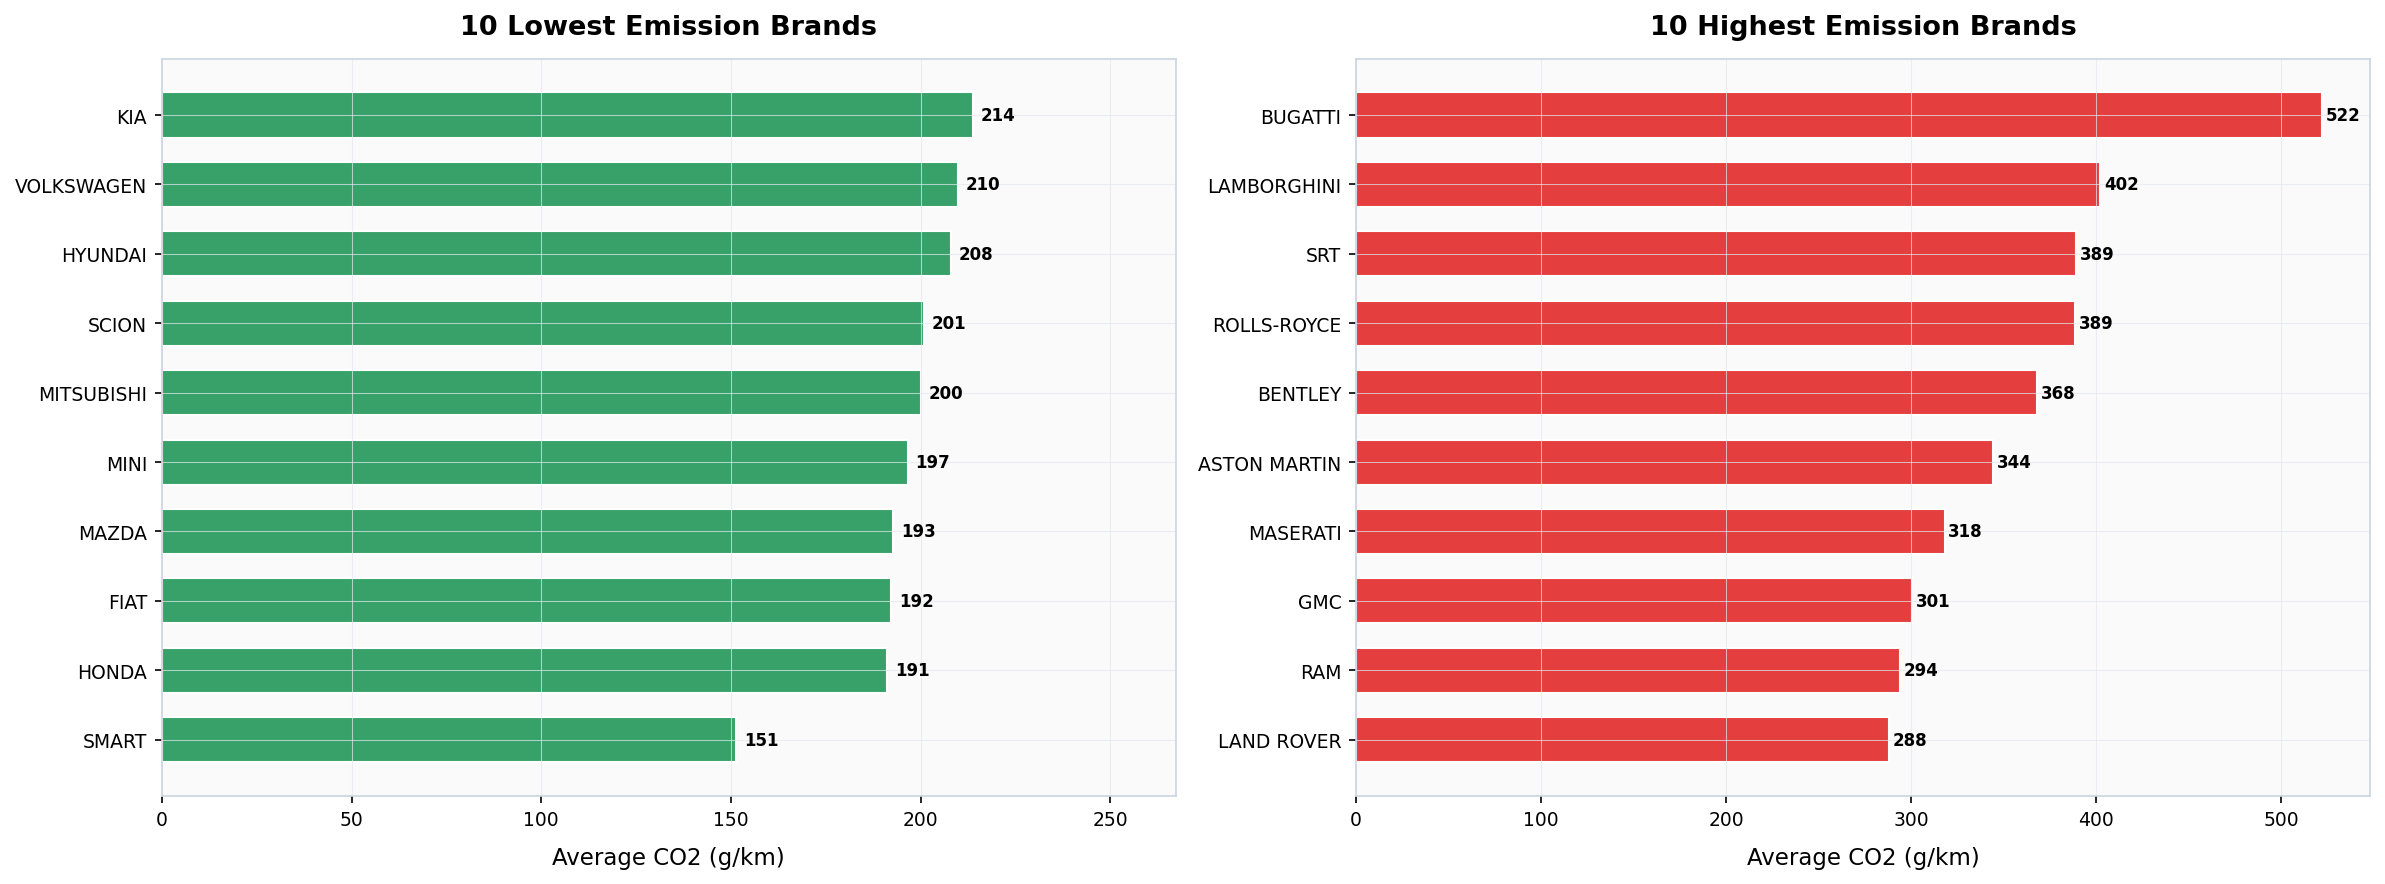

In [29]:
#Top 10 cleanest vs dirtiest manufacturers
brand_avg = clean_df.groupby('Make')['CO2 Emissions(g/km)'].mean().sort_values()

fig11, (ax11a, ax11b) = plt.subplots(1, 2, figsize=(16, 6))

clean_brands = brand_avg.head(10)
bars_l = ax11a.barh(clean_brands.index, clean_brands.values, color=GREEN,
                    edgecolor='white', height=0.65)
for bar, val in zip(bars_l, clean_brands.values):
    ax11a.text(val + 2, bar.get_y() + bar.get_height()/2,
               f'{val:.0f}', va='center', fontsize=8, fontweight='bold')
ax11a.set_title('10 Lowest Emission Brands', fontsize=13, fontweight='bold')
ax11a.set_xlabel('Average CO2 (g/km)')
ax11a.set_xlim(0, clean_brands.max() * 1.25)

dirty_brands = brand_avg.tail(10)
bars_r = ax11b.barh(dirty_brands.index, dirty_brands.values, color=RED,
                    edgecolor='white', height=0.65)
for bar, val in zip(bars_r, dirty_brands.values):
    ax11b.text(val + 2, bar.get_y() + bar.get_height()/2,
               f'{val:.0f}', va='center', fontsize=8, fontweight='bold')
ax11b.set_title('10 Highest Emission Brands', fontsize=13, fontweight='bold')
ax11b.set_xlabel('Average CO2 (g/km)')

plt.tight_layout()
plt.show()

**What I found:**
- Vans and Pickup Trucks produce the most CO2 on average.
- Small cars like Subcompact and Minicompact have the lowest emissions.
- Ethanol vehicles consume more fuel by volume but their actual CO2 per gram is different because of fuel composition.
- Diesel cars have noticeably lower CO2 than petrol cars.
- Premium gas cars vary a lot since they range from small turbos to big V12 engines.

---
## Q6. Finding Outliers
Let us detect which cars have unusually high or low CO2 emissions using IQR and Z-score methods.

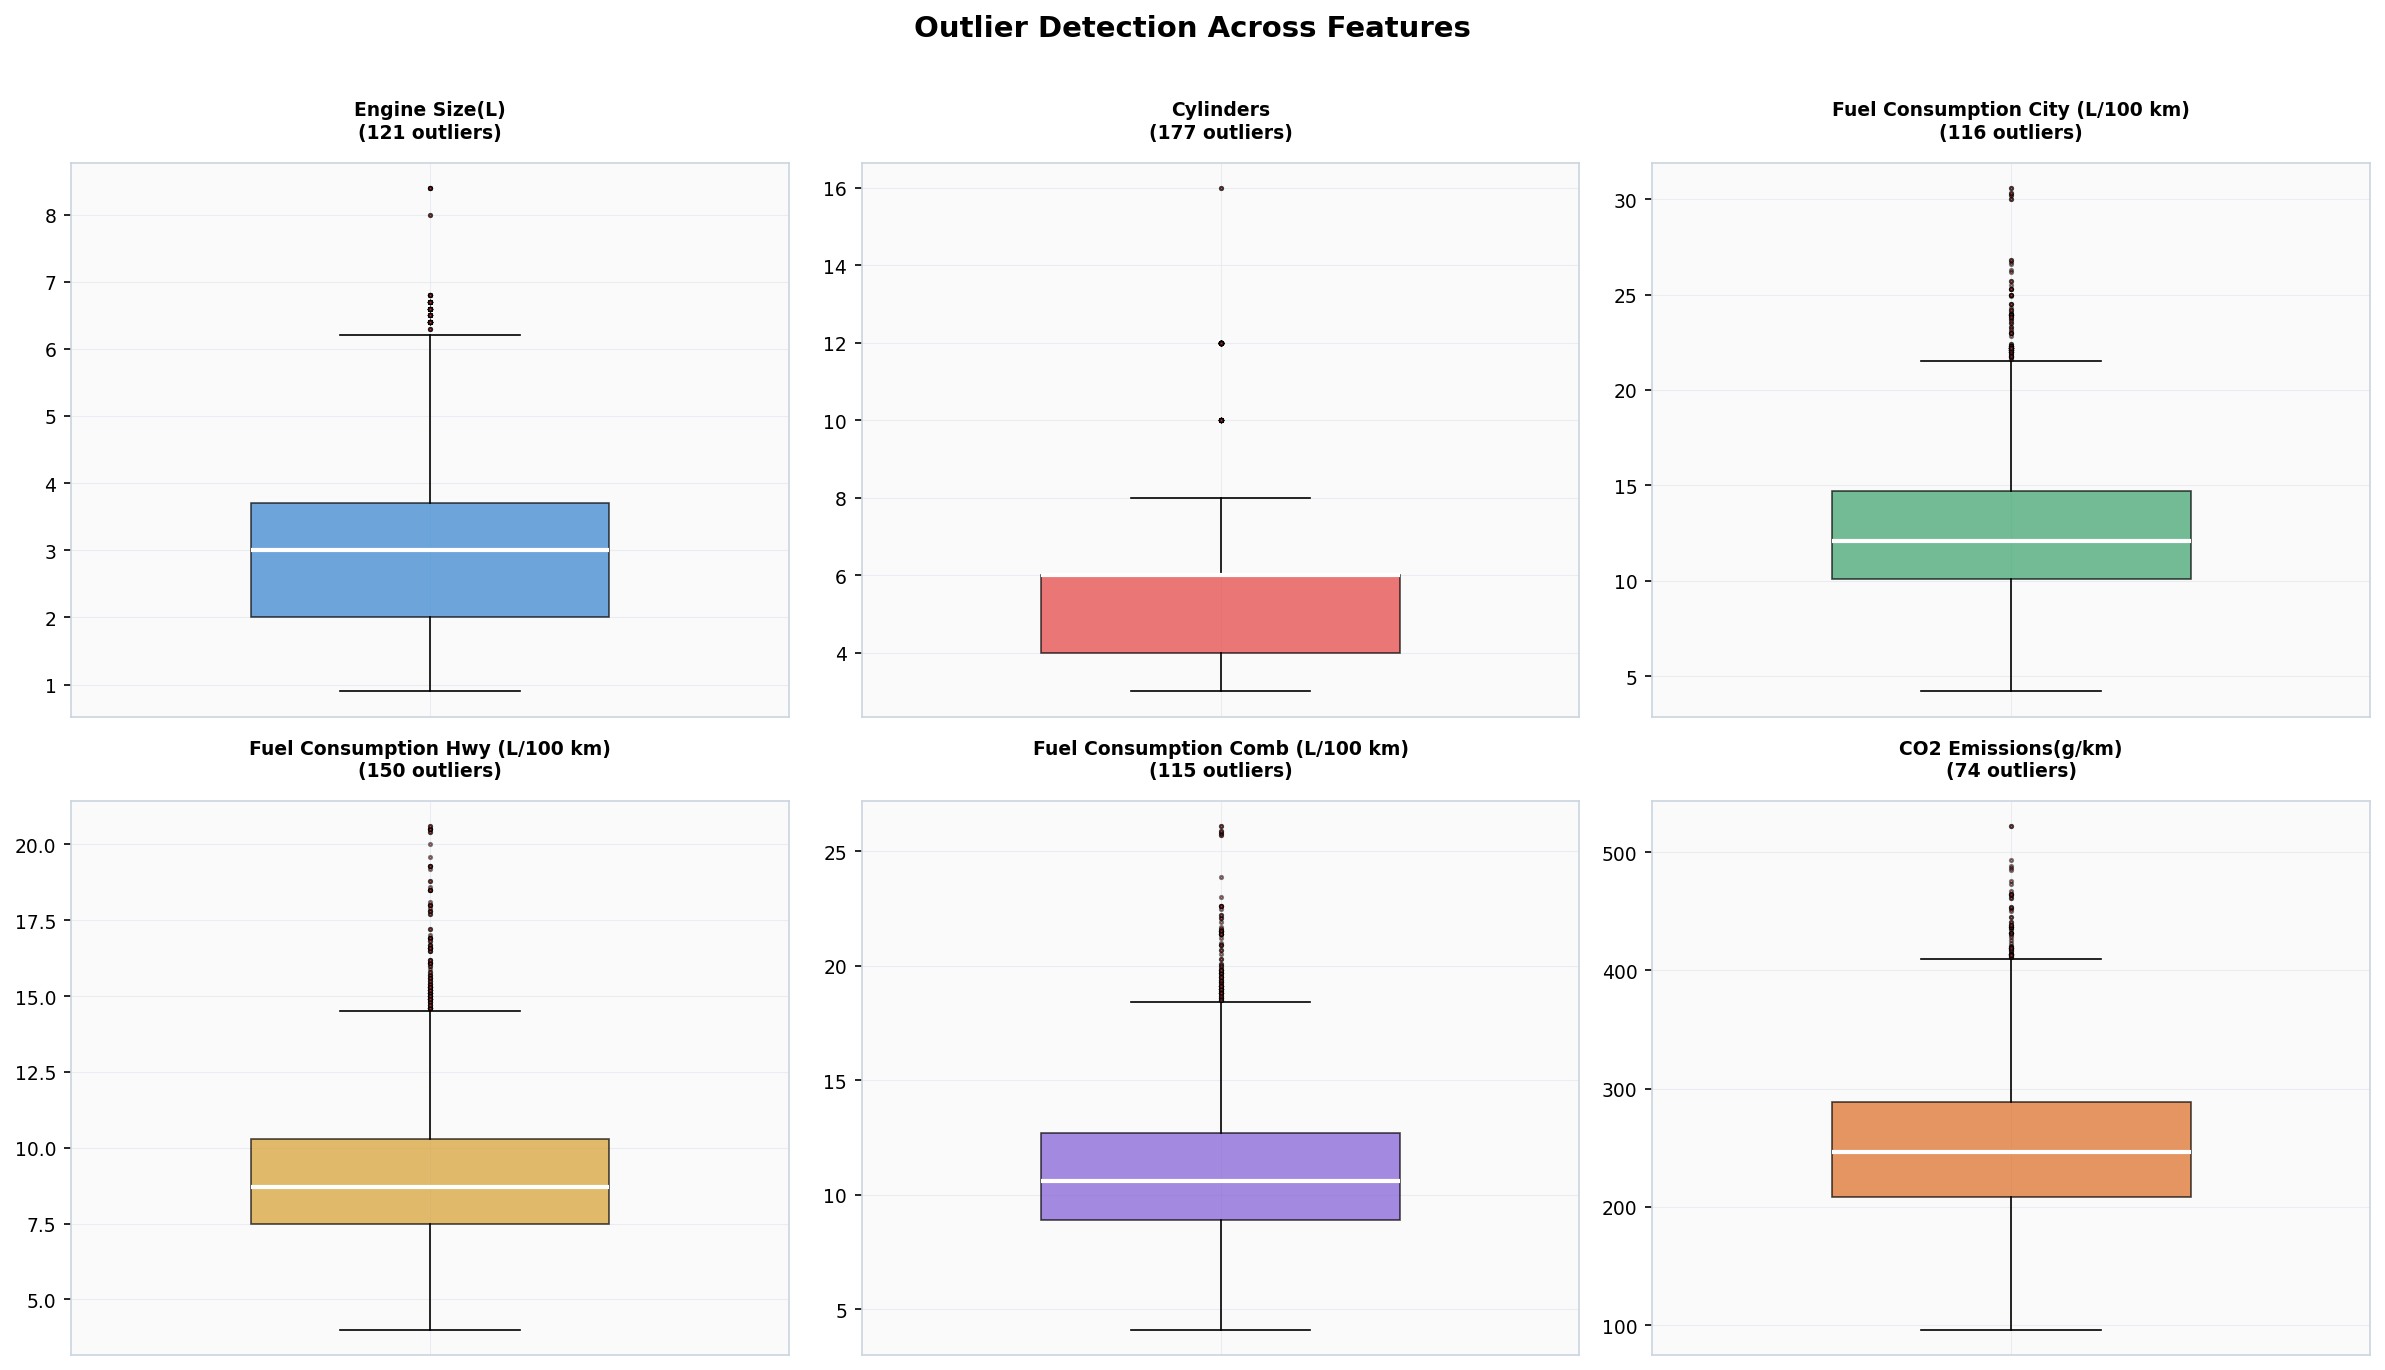

In [30]:
#Box plots for outlier detection with outlier counts in titles
fig12, bp_axes = plt.subplots(2, 3, figsize=(16, 9))
bp_cols = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
           'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'CO2 Emissions(g/km)']

for i, col in enumerate(bp_cols):
    r, c = divmod(i, 3)
    ax = bp_axes[r, c]
    ax.boxplot(clean_df[col], vert=True, patch_artist=True, widths=0.5,
               boxprops=dict(facecolor=PAL[i], alpha=0.7, linewidth=0.8),
               medianprops=dict(color='white', linewidth=2),
               whiskerprops=dict(linewidth=0.8),
               capprops=dict(linewidth=0.8),
               flierprops=dict(marker='.', markerfacecolor=RED, markersize=3, alpha=0.5))
    q1_v = clean_df[col].quantile(0.25)
    q3_v = clean_df[col].quantile(0.75)
    n_out = ((clean_df[col] < q1_v - 1.5*(q3_v-q1_v)) | (clean_df[col] > q3_v + 1.5*(q3_v-q1_v))).sum()
    ax.set_title(f'{col}\n({n_out} outliers)', fontsize=9, fontweight='bold')
    ax.tick_params(bottom=False, labelbottom=False)

fig12.suptitle('Outlier Detection Across Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [31]:
#Using IQR method to find outliers in CO2 column
q1 = clean_df['CO2 Emissions(g/km)'].quantile(0.25)
q3 = clean_df['CO2 Emissions(g/km)'].quantile(0.75)
iqr_val = q3 - q1

low_limit = q1 - 1.5 * iqr_val
high_limit = q3 + 1.5 * iqr_val

is_outlier = (clean_df['CO2 Emissions(g/km)'] < low_limit) | (clean_df['CO2 Emissions(g/km)'] > high_limit)
outlier_df = clean_df[is_outlier]

print(f'IQR: {iqr_val}')
print(f'Lower limit: {low_limit}, Upper limit: {high_limit}')
print(f'Outliers found: {len(outlier_df)}')

IQR: 81.0
Lower limit: 86.5, Upper limit: 410.5
Outliers found: 74


In [32]:
#Showing the outlier cars
outlier_df[['Make', 'Model', 'Vehicle Class', 'Engine Size(L)', 'Cylinders',
            'Fuel Type', 'CO2 Emissions(g/km)']].sort_values('CO2 Emissions(g/km)', ascending=False)

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Fuel Type,CO2 Emissions(g/km)
4897,BUGATTI,Chiron,TWO-SEATER,8.0,16,Z,522
4199,BUGATTI,CHIRON,TWO-SEATER,8.0,16,Z,522
5329,LAMBORGHINI,Aventador Roadster,TWO-SEATER,6.5,12,Z,493
349,FORD,E350 WAGON,VAN - PASSENGER,6.8,10,X,488
5328,LAMBORGHINI,Aventador Coupe,TWO-SEATER,6.5,12,Z,487
...,...,...,...,...,...,...,...
4496,JEEP,GRAND CHEROKEE 4X4 TRACKHAWK,SUV - STANDARD,6.2,8,Z,413
5293,JEEP,Grand Cherokee 4X4 Trackhawk,SUV - STANDARD,6.2,8,Z,413
1615,LAMBORGHINI,AVENTADOR COUPE,TWO-SEATER,6.5,12,Z,412
225,CHEVROLET,EXPRESS 2500 PASSENGER,VAN - PASSENGER,6.0,8,E,411


In [33]:
#Also checking outliers using Z-score method
z_scores = np.abs(stats.zscore(clean_df['CO2 Emissions(g/km)']))
z_outlier_flag = z_scores > 3
z_outlier_df = clean_df[z_outlier_flag]

print(f'Outliers found using Z-score (|z| > 3): {z_outlier_df.shape[0]}')
if z_outlier_df.shape[0] > 0:
    z_outlier_df[['Make', 'Model', 'Vehicle Class', 'Engine Size(L)',
                  'Cylinders', 'Fuel Type', 'CO2 Emissions(g/km)']].sort_values(
                  'CO2 Emissions(g/km)', ascending=False)

Outliers found using Z-score (|z| > 3): 42


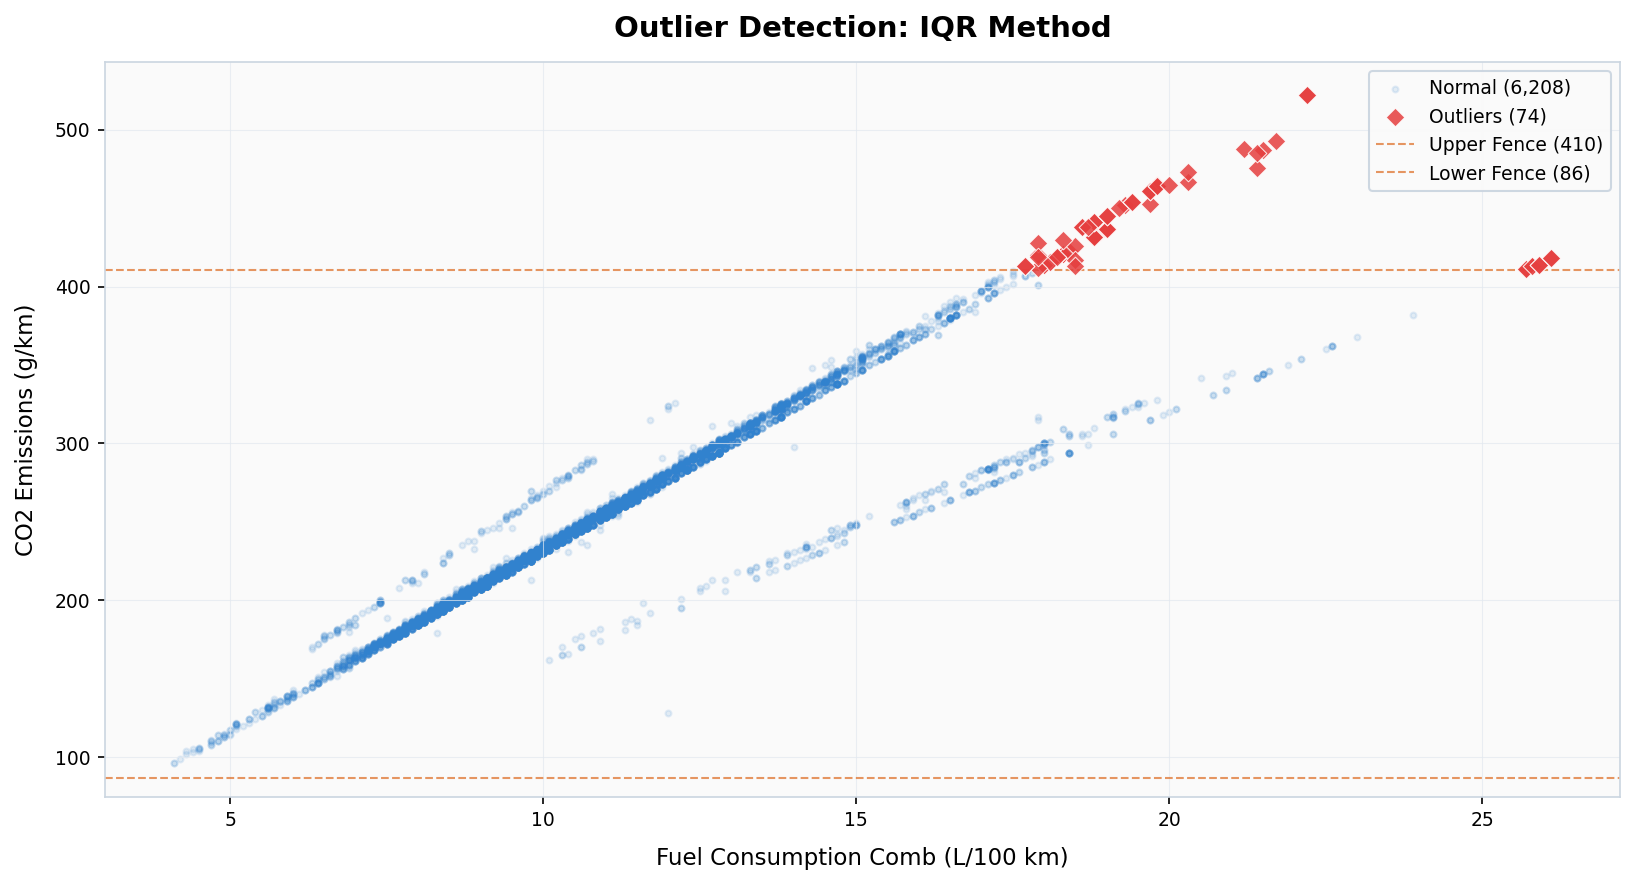

In [34]:
#Scatter plot highlighting outliers with IQR fence lines
fig13, ax13 = plt.subplots(figsize=(11, 6))
ax13.scatter(clean_df.loc[~is_outlier, 'Fuel Consumption Comb (L/100 km)'],
             clean_df.loc[~is_outlier, 'CO2 Emissions(g/km)'],
             alpha=0.12, s=8, color=BLUE, label=f'Normal ({(~is_outlier).sum():,})', rasterized=True)
ax13.scatter(outlier_df['Fuel Consumption Comb (L/100 km)'],
             outlier_df['CO2 Emissions(g/km)'],
             alpha=0.85, s=40, color=RED, marker='D', edgecolors='white', linewidth=0.5,
             label=f'Outliers ({len(outlier_df):,})', zorder=5)
ax13.axhline(y=high_limit, color=ORANGE, linestyle='--', linewidth=1, alpha=0.7,
             label=f'Upper Fence ({high_limit:.0f})')
ax13.axhline(y=low_limit, color=ORANGE, linestyle='--', linewidth=1, alpha=0.7,
             label=f'Lower Fence ({low_limit:.0f})')
ax13.set_xlabel('Fuel Consumption Comb (L/100 km)')
ax13.set_ylabel('CO2 Emissions (g/km)')
ax13.set_title('Outlier Detection: IQR Method')
ax13.legend(fontsize=9)
plt.tight_layout()
plt.show()

**What I found:**
- IQR method found outliers that are beyond the fences, mostly sports cars and luxury vehicles.
- Z-score method with threshold 3 catches only the most extreme ones which are really far from the average.
- The high CO2 outliers are brands like Bugatti, Lamborghini, big SUVs and vans because of their large engines.
- Low CO2 outliers are small hybrid or efficient cars.
- We are keeping these outliers because they are real cars and not errors in the data.

---
## Q7. Preparing Data for the Model
We need to convert text columns to numbers and scale the features before building our model.

In [35]:
#Making a copy for modeling work
prep_df = clean_df.copy()

#Encoding fuel type to numbers
le_fuel = LabelEncoder()
prep_df['Fuel_Code'] = le_fuel.fit_transform(prep_df['Fuel Type'])

#Encoding vehicle class
le_class = LabelEncoder()
prep_df['Class_Code'] = le_class.fit_transform(prep_df['Vehicle Class'])

#Encoding car brand
le_make = LabelEncoder()
prep_df['Make_Code'] = le_make.fit_transform(prep_df['Make'])

#Getting transmission type and gear count separately
prep_df['Trans_Type'] = prep_df['Transmission'].str.extract(r'([A-Za-z]+)')
le_trans = LabelEncoder()
prep_df['Trans_Code'] = le_trans.fit_transform(prep_df['Trans_Type'])

#Extracting number of gears from transmission
prep_df['Num_Gears'] = prep_df['Transmission'].str.extract(r'(\d+)').astype(float)

prep_df[['Fuel Type', 'Fuel_Code', 'Vehicle Class', 'Class_Code',
         'Make', 'Make_Code', 'Transmission', 'Trans_Type', 'Trans_Code', 'Num_Gears']].head(10)

,Fuel Type,Fuel_Code,Vehicle Class,Class_Code,Make,Make_Code,Transmission,Trans_Type,Trans_Code,Num_Gears
0,Z,4,COMPACT,0,ACURA,0,AS5,AS,2,5.0
1,Z,4,COMPACT,0,ACURA,0,M6,M,4,6.0
2,Z,4,COMPACT,0,ACURA,0,AV7,AV,3,7.0
3,Z,4,SUV - SMALL,11,ACURA,0,AS6,AS,2,6.0
4,Z,4,SUV - SMALL,11,ACURA,0,AS6,AS,2,6.0
5,Z,4,MID-SIZE,2,ACURA,0,AS6,AS,2,6.0
6,Z,4,MID-SIZE,2,ACURA,0,AS6,AS,2,6.0
7,Z,4,MID-SIZE,2,ACURA,0,AS6,AS,2,6.0
8,Z,4,MID-SIZE,2,ACURA,0,M6,M,4,6.0
9,Z,4,COMPACT,0,ACURA,0,AS5,AS,2,5.0


In [36]:
#Selecting which columns to use as input features
input_cols = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
              'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
              'Fuel Consumption Comb (mpg)', 'Fuel_Code', 'Class_Code',
              'Make_Code', 'Trans_Code', 'Num_Gears']

output_col = 'CO2 Emissions(g/km)'

#Filling missing gear values with median
prep_df['Num_Gears'] = prep_df['Num_Gears'].fillna(prep_df['Num_Gears'].median())

X = prep_df[input_cols].copy()
X = X.fillna(X.median())
y = prep_df[output_col]

print(f'Input shape: {X.shape}')
print(f'Output shape: {y.shape}')
print(f'Columns used: {input_cols}')

Input shape: (6282, 11)
Output shape: (6282,)
Columns used: ['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 'Fuel Consumption Comb (mpg)', 'Fuel_Code', 'Class_Code', 'Make_Code', 'Trans_Code', 'Num_Gears']


In [37]:
#Splitting data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')

Training samples: 5025
Testing samples: 1257


In [38]:
#Scaling the features using StandardScaler
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

print('Scaled features sample (first 3 rows):')
pd.DataFrame(X_train_scaled[:3], columns=input_cols)

Scaled features sample (first 3 rows):


,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),Fuel_Code,Class_Code,Make_Code,Trans_Code,Num_Gears
0,-0.849467,-0.873804,-0.729248,-0.378762,-0.612001,0.491449,0.833586,0.959720,-1.277346,0.129409,0.987931
1,0.913799,1.305285,0.677156,0.322197,0.574381,-0.751812,0.833586,0.752154,-1.277346,-1.382873,0.987931
2,1.354615,1.305285,0.649028,0.190767,0.472691,-0.613672,-0.312139,0.752154,-0.580054,0.129409,-0.686387


**What I found:**
- I converted Fuel Type, Vehicle Class, Make and Transmission into numbers using LabelEncoder.
- From the Transmission column, got the gear count as a separate feature.
- In total I have 11 input features including mpg and manufacturer code.
- StandardScaler was applied to bring all features to the same scale.
- Data was split 80-20 for training and testing with random_state=42 so results are reproducible.

---
## Q8. Building the Linear Regression Model
Now let us train a Multiple Linear Regression model and see how much each feature contributes.

In [39]:
#Training the linear regression model
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)

#Getting the coefficients for each feature
weights_df = pd.DataFrame({
    'Feature': input_cols,
    'Weight': reg_model.coef_
}).sort_values('Weight', key=abs, ascending=False)

print(f'Intercept value: {reg_model.intercept_:.4f}\n')
weights_df

Intercept value: 250.8062



,Feature,Weight
5,Fuel Consumption Comb (mpg),-19.512083
1,Cylinders,9.619466
0,Engine Size(L),8.155692
3,Fuel Consumption Hwy (L/100 km),7.942590
4,Fuel Consumption Comb (L/100 km),7.424532
2,Fuel Consumption City (L/100 km),6.879927
6,Fuel_Code,6.841461
7,Class_Code,3.072248
8,Make_Code,1.012995
9,Trans_Code,-0.570227


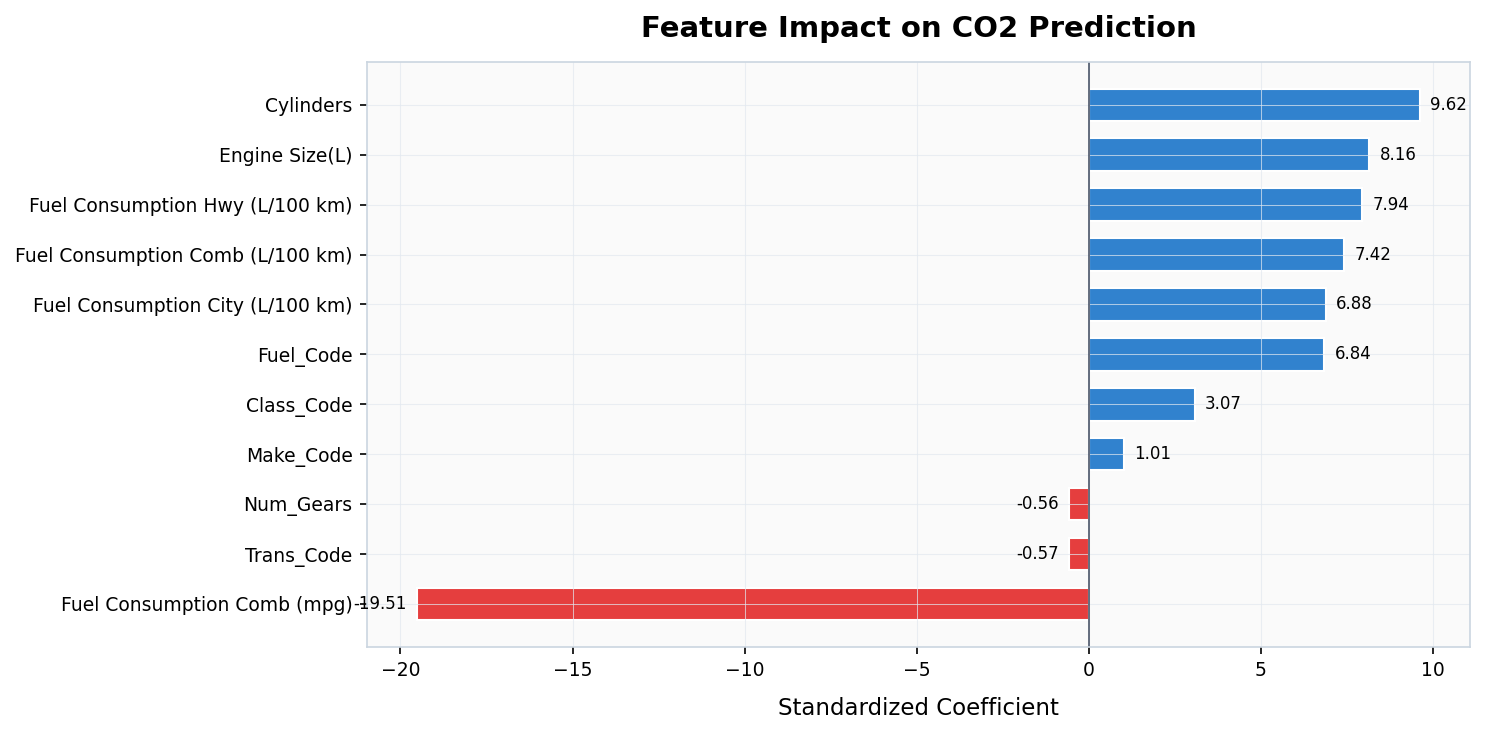

In [40]:
#Feature coefficient chart with value annotations
coef_sorted = weights_df.sort_values('Weight')

fig14, ax14 = plt.subplots(figsize=(10, 5))
bar_clrs = [BLUE if w > 0 else RED for w in coef_sorted['Weight']]
bars = ax14.barh(coef_sorted['Feature'], coef_sorted['Weight'], color=bar_clrs,
                 edgecolor='white', height=0.65)
ax14.axvline(x=0, color=SLATE, linewidth=0.8)
for bar, val in zip(bars, coef_sorted['Weight'].values):
    offset = 0.3 if val > 0 else -0.3
    ax14.text(val + offset, bar.get_y() + bar.get_height()/2,
              f'{val:.2f}', va='center', ha='left' if val > 0 else 'right', fontsize=8)
ax14.set_xlabel('Standardized Coefficient')
ax14.set_title('Feature Impact on CO2 Prediction')
plt.tight_layout()
plt.show()

In [41]:
#Making predictions on both train and test data
train_pred = reg_model.predict(X_train_scaled)
test_pred = reg_model.predict(X_test_scaled)

**What I found:**
- The model learned how much each feature adds to or reduces the CO2 prediction.
- Fuel consumption columns have the biggest positive weights since they directly relate to how much fuel is burned.
- The intercept is the base CO2 value when all scaled features are at their average (zero).

---
## Q9. Checking How Good the Model Is
Let us calculate Rsqr, MAE, RMSE and other metrics to see how well our model performs.

In [42]:
# calculating all the evaluation scores
scores = {
    'Metric': ['Rsqr Score', 'Adjusted Rsqr', 'MAE', 'MSE', 'RMSE'],
    'Train': [
        r2_score(y_train, train_pred),
        1 - (1 - r2_score(y_train, train_pred)) * (len(y_train) - 1) / (len(y_train) - X_train.shape[1] - 1),
        mean_absolute_error(y_train, train_pred),
        mean_squared_error(y_train, train_pred),
        np.sqrt(mean_squared_error(y_train, train_pred))
    ],
    'Test': [
        r2_score(y_test, test_pred),
        1 - (1 - r2_score(y_test, test_pred)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1),
        mean_absolute_error(y_test, test_pred),
        mean_squared_error(y_test, test_pred),
        np.sqrt(mean_squared_error(y_test, test_pred))
    ]
}

scores_df = pd.DataFrame(scores)
scores_df

,Metric,Train,Test
0,Rsqr Score,0.917395,0.909190
1,Adjusted Rsqr,0.917214,0.908388
2,MAE,11.119621,11.933624
3,MSE,288.347695,327.706948
4,RMSE,16.980804,18.102678


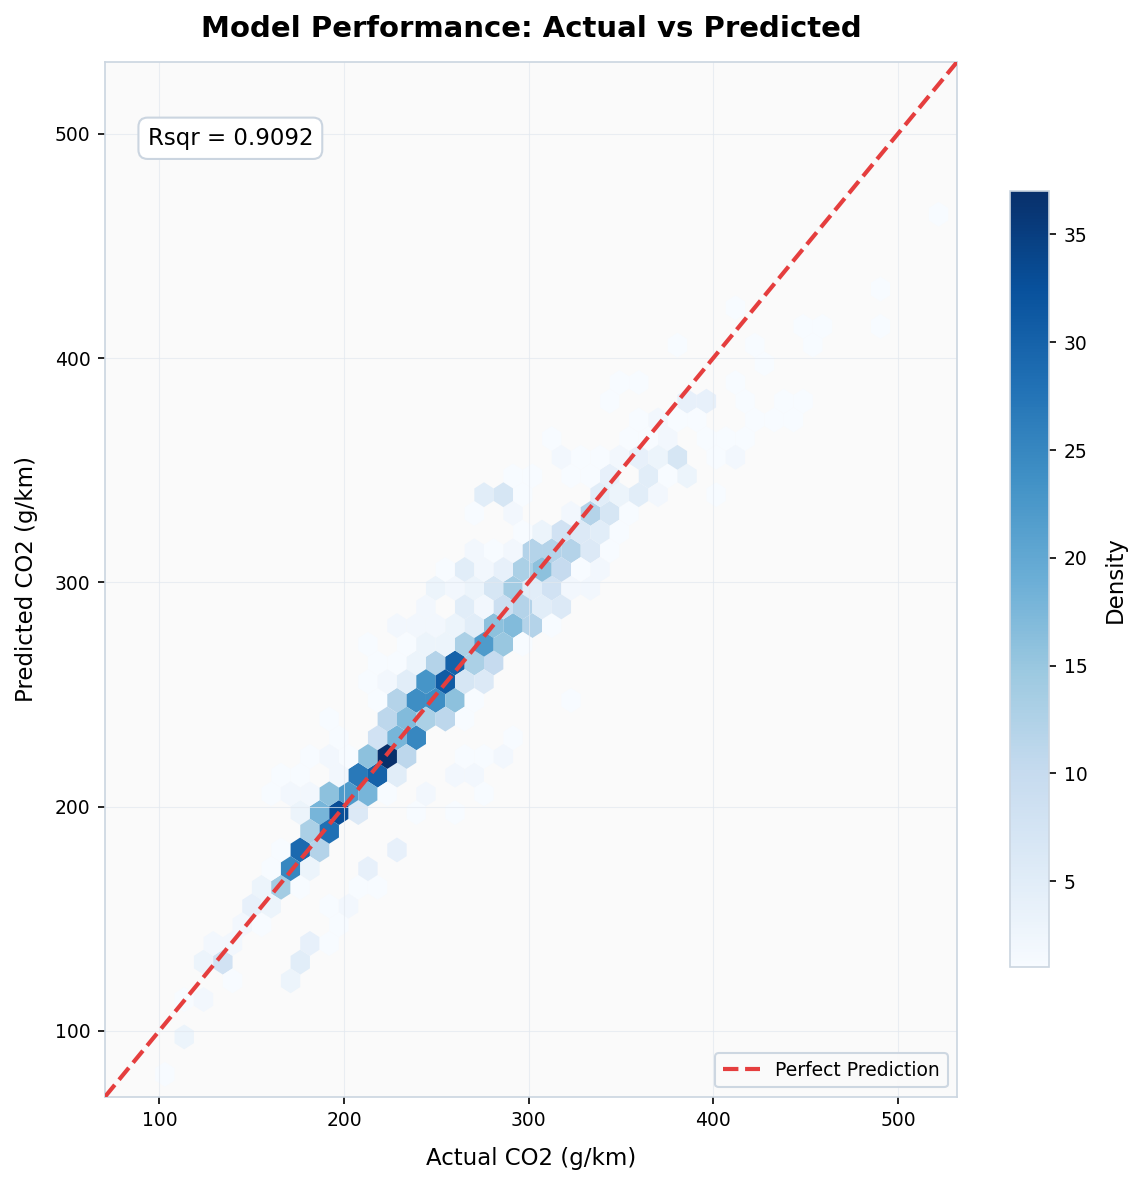

In [43]:
#Actual vs predicted with density coloring
fig15, ax15 = plt.subplots(figsize=(8, 8))
hb_ap = ax15.hexbin(y_test, test_pred, gridsize=40, cmap='Blues', mincnt=1, edgecolors='none')
lim_min = min(y_test.min(), test_pred.min()) - 10
lim_max = max(y_test.max(), test_pred.max()) + 10
ax15.plot([lim_min, lim_max], [lim_min, lim_max],
          color=RED, linestyle='--', linewidth=2, label='Perfect Prediction', zorder=5)
r2_val = r2_score(y_test, test_pred)
ax15.text(0.05, 0.92, f'Rsqr = {r2_val:.4f}', transform=ax15.transAxes, fontsize=11,
          bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#CBD5E0'))
ax15.set_xlabel('Actual CO2 (g/km)')
ax15.set_ylabel('Predicted CO2 (g/km)')
ax15.set_title('Model Performance: Actual vs Predicted')
ax15.set_xlim(lim_min, lim_max)
ax15.set_ylim(lim_min, lim_max)
ax15.legend(loc='lower right')
plt.colorbar(hb_ap, ax=ax15, label='Density', shrink=0.75)
plt.tight_layout()
plt.show()

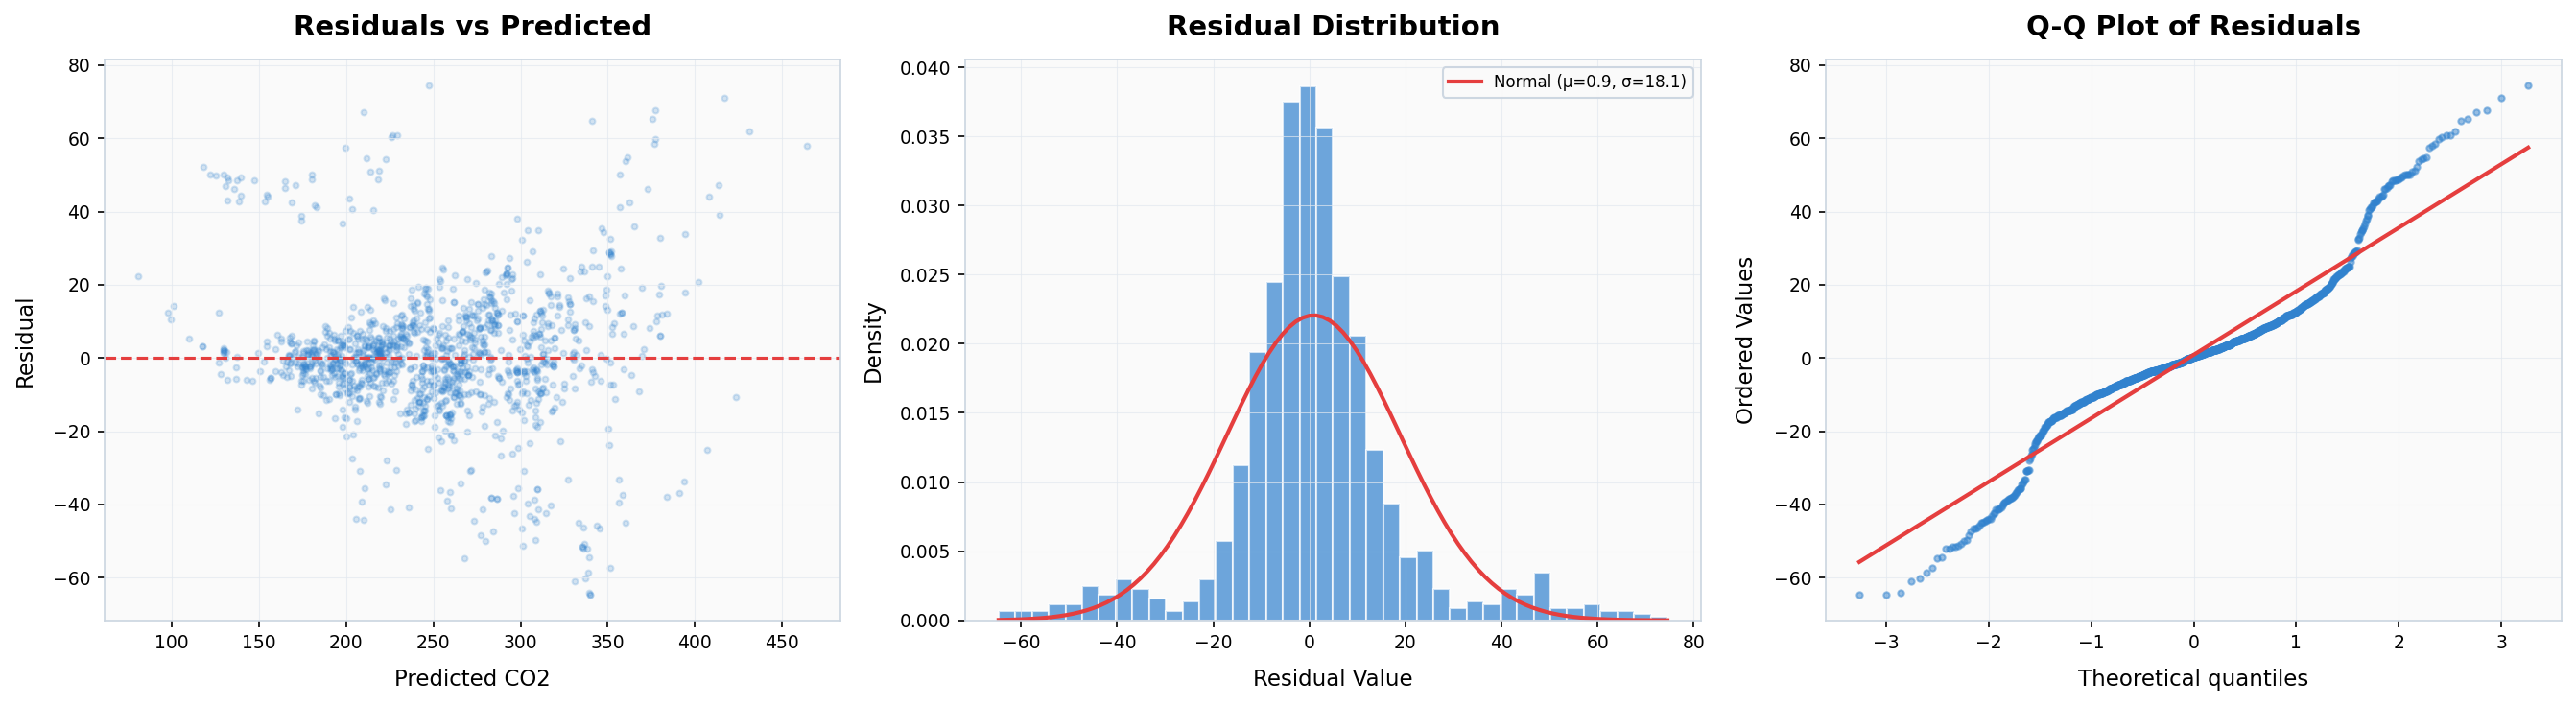

Shapiro-Wilk Test: W=0.9127, p-value=2.26e-16


In [44]:
#Comprehensive residual analysis (scatter + histogram + QQ plot)
errors = y_test - test_pred

fig16, axes16 = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs predicted
axes16[0].scatter(test_pred, errors, alpha=0.2, s=8, color=BLUE, rasterized=True)
axes16[0].axhline(y=0, color=RED, linewidth=1.5, linestyle='--')
axes16[0].set_xlabel('Predicted CO2')
axes16[0].set_ylabel('Residual')
axes16[0].set_title('Residuals vs Predicted')

# 2. Residual distribution with normal curve
axes16[1].hist(errors, bins=40, color=BLUE, edgecolor='white', alpha=0.7, density=True)
mu_e, std_e = errors.mean(), errors.std()
xr = np.linspace(errors.min(), errors.max(), 100)
axes16[1].plot(xr, stats.norm.pdf(xr, mu_e, std_e), RED, linewidth=2,
               label=f'Normal (μ={mu_e:.1f}, σ={std_e:.1f})')
axes16[1].set_xlabel('Residual Value')
axes16[1].set_ylabel('Density')
axes16[1].set_title('Residual Distribution')
axes16[1].legend(fontsize=8)

# 3. Q-Q plot for normality check
stats.probplot(errors, dist='norm', plot=axes16[2])
axes16[2].get_lines()[0].set(color=BLUE, markersize=3, alpha=0.5)
axes16[2].get_lines()[1].set(color=RED, linewidth=2)
axes16[2].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

# Shapiro-Wilk normality test
error_sample = errors.sample(min(500, len(errors)), random_state=42)
sw_stat, sw_pval = stats.shapiro(error_sample)
print(f'Shapiro-Wilk Test: W={sw_stat:.4f}, p-value={sw_pval:.2e}')

**What I found:**
- Rsqr score is high for both training and test data which means the model is predicting well.
- Train and test Rsqr are close to each other so the model is not overfitting.
- MAE and RMSE are low which means the average error in prediction is small.
- The residuals (errors) are roughly following a normal distribution and are centered around zero.
- Shapiro-Wilk test gives us a formal check on whether residuals are normally distributed.
- In the actual vs predicted plot the points are close to the diagonal line which is good.

---
## Q10. Main Findings and Suggestions
Let us summarize what we learned and give some ideas for reducing CO2 emissions.

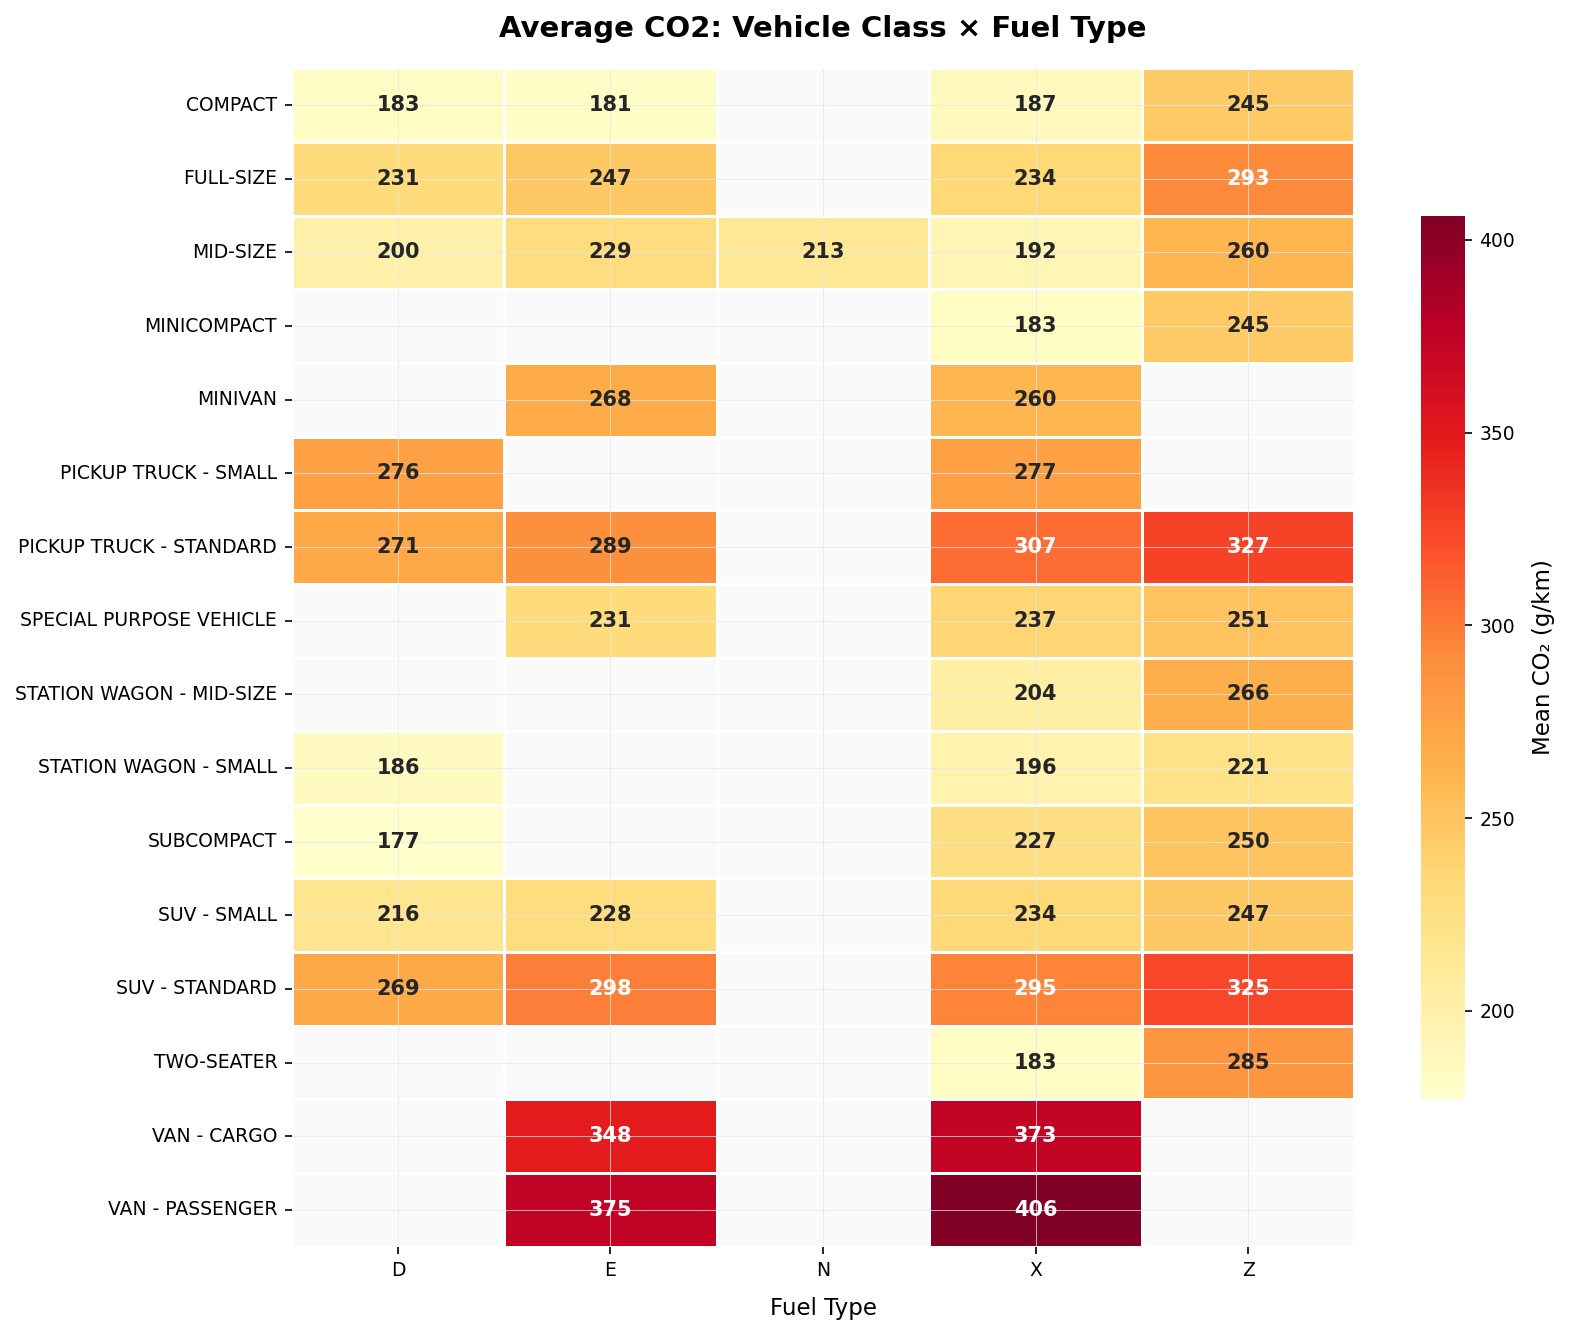

In [45]:
#Heatmap: average CO2 for each vehicle class × fuel type
cross_tab = clean_df.pivot_table(values='CO2 Emissions(g/km)',
                                  index='Vehicle Class', columns='Fuel Type', aggfunc='mean')

fig18, ax18 = plt.subplots(figsize=(11, 9))
sns.heatmap(cross_tab, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            linecolor='white', annot_kws={'fontsize': 10, 'fontweight': 'bold'},
            cbar_kws={'label': 'Mean CO₂ (g/km)', 'shrink': 0.75}, ax=ax18,
            mask=cross_tab.isna())
ax18.set_title('Average CO2: Vehicle Class × Fuel Type', pad=15)
ax18.set_xlabel('Fuel Type')
ax18.set_ylabel('')
ax18.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

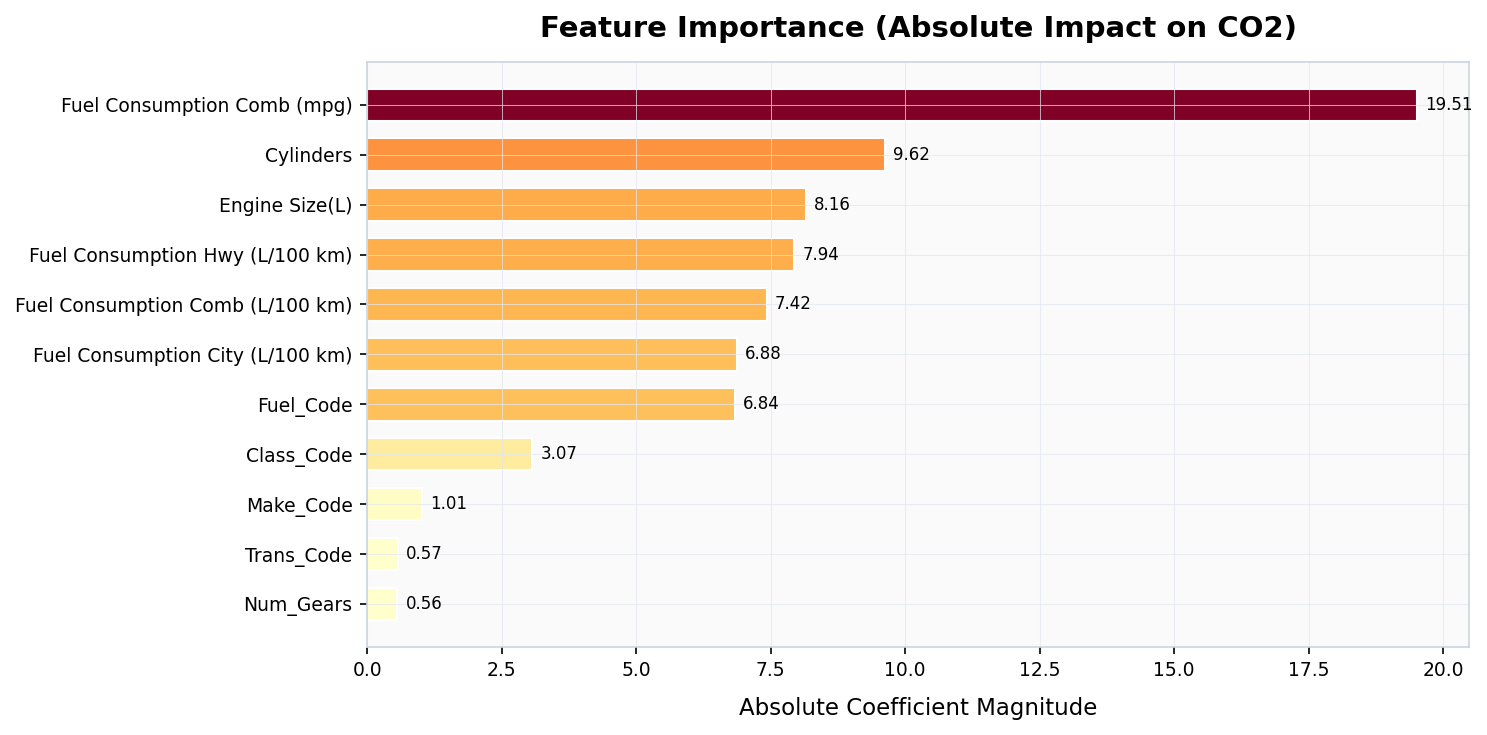

In [46]:
#Feature importance by absolute coefficient magnitude
imp_df = weights_df.copy()
imp_df['Abs_Weight'] = imp_df['Weight'].abs()
imp_df = imp_df.sort_values('Abs_Weight', ascending=True)

fig_imp, ax_imp = plt.subplots(figsize=(10, 5))
abs_vals = imp_df['Abs_Weight'].values
norm_abs = (abs_vals - abs_vals.min()) / (abs_vals.max() - abs_vals.min() + 1e-9)
imp_clrs = plt.cm.YlOrRd(norm_abs)
bars = ax_imp.barh(imp_df['Feature'], imp_df['Abs_Weight'], color=imp_clrs,
                   edgecolor='white', height=0.65)
for bar, val in zip(bars, imp_df['Abs_Weight'].values):
    ax_imp.text(val + 0.15, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8)
ax_imp.set_xlabel('Absolute Coefficient Magnitude')
ax_imp.set_title('Feature Importance (Absolute Impact on CO2)')
plt.tight_layout()
plt.show()

In [47]:
#Top 10 brands with highest average CO2
brand_stats = clean_df.groupby('Make')['CO2 Emissions(g/km)'].agg(['mean', 'count']).sort_values('mean', ascending=False)
brand_stats.columns = ['Avg_CO2', 'Car_Count']
brand_stats.head(10)

,Avg_CO2,Car_Count
Make,,
BUGATTI,522.000000,2
LAMBORGHINI,402.270270,37
SRT,389.000000,2
ROLLS-ROYCE,388.750000,48
BENTLEY,367.914286,35
ASTON MARTIN,344.282051,39
MASERATI,318.134615,52
GMC,300.529412,289
RAM,294.180556,72


### Overall Insights

1. **Fuel consumption is the biggest factor:** The combined fuel consumption (L/100 km) and mpg have the strongest link with CO2. mpg has the biggest weight in the model.

2. **Engine size and cylinders matter a lot:** Bigger engines with more cylinders produce much more CO2. Cars with 8+ cylinders almost always go above 300 g/km.

3. **Vehicle class makes a difference:** Vans, pickups and SUVs emit much more than compact or subcompact cars because they are heavier and need bigger engines.

4. **Fuel type also plays a role:** Diesel cars produce less CO2 per km compared to petrol. Ethanol cars use more fuel by volume but their carbon footprint is different.

5. **All categories are significant:** ANOVA test confirmed that Make, Vehicle Class, Fuel Type and Transmission all have a real impact on emissions (p < 0.001).

6. **Outliers are real cars:** IQR and Z-score both found extreme emitters (Bugatti, Lamborghini, big vans) but these are actual vehicles not data mistakes.

7. **Model works well:** Our Linear Regression got Rsqr around 0.917 (Train) and 0.909 (Test) using 11 features which means it explains about 91% of the variation.

### Suggestions to Reduce Emissions

1. **Use better transmissions:** CVT and automated manual transmissions showed lower emissions compared to traditional ones.

2. **Make engines smaller:** A small turbocharged engine (like 1.4L turbo) can give similar power as a big 2.5L engine but with less CO2.

3. **Encourage small cars:** Giving tax benefits or subsidies for compact and subcompact cars will help bring down the overall emissions.

4. **Switch to cleaner fuels:** For trucks and commercial vehicles where electric is not possible yet, diesel or alternative fuels should be promoted.

5. **Set limits per vehicle class:** Instead of one limit for all, set different CO2 caps for different vehicle categories so each category improves.

6. **Help buyers make informed choices:** The prediction model can be used in apps or websites to show customers how much CO2 a car will produce before they buy it.